# DodoGo Taxi Platform: Exploratory Demand Analysis

This notebook prepares the main operational evidence used in the thesis. It combines the old and new platform order exports, then studies growth, demand timing, wait time, geography, cancellation patterns, customer and driver segments, forecasting, and external factors.

The purpose is practical. The analysis should show where demand appears, where operations fail, and which findings can guide supply planning, retention, product changes, and market strategy for a ride-hailing platform in Mauritius.

## 1. Setup and Libraries

The first cell loads the libraries used for data preparation, visualization, forecasting, clustering, and basic machine learning. Optional libraries are kept commented so the notebook can run in a lighter environment.

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels
# !pip install prophet  # optional, for Section 8.2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 8), 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 120
})

C = {
    'primary': '#1565C0', 'secondary': '#FF5722', 'success': '#4CAF50',
    'warning': '#FF9800', 'danger': '#E53935', 'purple': '#9C27B0',
    'old': '#2196F3', 'new': '#FF5722', 'gray': '#9E9E9E'
}
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Cleaning and Unification

DodoGo has order data from two platform phases. The old platform covers November 2023 to October 2025, and the new platform starts from October 2025. The exports use different encodings, column names, status labels, and date formats.

This section brings both exports into one comparable structure. After that, the same indicators can be calculated across the full period: completed orders, conversion, timing, geography, cancellations, and basic trip characteristics.

In [ ]:
# Load datasets
df_new = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
df_old = pd.read_csv("../data/raw/orders_old_platform.csv",
                       sep=";", encoding="latin1", low_memory=False, on_bad_lines='skip')

# New platform cleaning
df_new['created'] = pd.to_datetime(df_new['Дата создания'], format="%d.%m.%Y %H:%M", errors='coerce')
for col in ['Стоимость', 'Суммарное расстояние (км)', 'Наличные', 'Комиссия с исполнителя']:
    df_new[col] = df_new[col].astype(str).str.replace(',', '.').astype(float)

df_new.rename(columns={
    'Стоимость': 'price', 'Суммарное расстояние (км)': 'distance_km',
    'Текущий статус': 'status', 'Тариф': 'tariff', 'Способ заказа': 'order_source',
    'Исполнитель': 'driver', 'Телефон клиента': 'client_phone',
    'Адрес подачи': 'pickup_address', 'Адрес назначения': 'dropoff_address',
    'Район адреса подачи': 'pickup_district', 'Наличные': 'cash_paid',
    'Комиссия с исполнителя': 'driver_commission'
}, inplace=True)

df_new['is_completed'] = df_new['status'].str.contains('Выполнен', na=False)
df_new['has_driver'] = df_new['driver'].notna() & (df_new['driver'].str.strip() != '')
df_new['hour'] = df_new['created'].dt.hour
df_new['day_of_week'] = df_new['created'].dt.dayofweek
df_new['date'] = df_new['created'].dt.date
df_new['month_num'] = df_new['created'].dt.month

# Old platform cleaning
df_old['created'] = pd.to_datetime(df_old['Created at'], errors='coerce')
df_old['Price'] = pd.to_numeric(df_old['Price'], errors='coerce')
df_old['Trip mileage'] = pd.to_numeric(df_old['Trip mileage'], errors='coerce')
df_old.rename(columns={'Price': 'price', 'Trip mileage': 'distance_km',
    'Status': 'status', 'Service class': 'tariff',
    'Passenger phone number': 'client_phone', 'From': 'pickup_address', 'To': 'dropoff_address'
}, inplace=True)
df_old['is_completed'] = df_old['status'] == 'Completed'
df_old['hour'] = df_old['created'].dt.hour
df_old['day_of_week'] = df_old['created'].dt.dayofweek
df_old['date'] = df_old['created'].dt.date

print(f"New platform: {len(df_new):,} orders ({df_new['created'].min().date()} to {df_new['created'].max().date()})")
print(f"  Completed: {df_new['is_completed'].sum():,} ({df_new['is_completed'].mean()*100:.1f}%)")
print(f"\nOld platform: {len(df_old):,} orders ({df_old['created'].min().date()} to {df_old['created'].max().date()})")
print(f"  Completed: {df_old['is_completed'].sum():,} ({df_old['is_completed'].mean()*100:.1f}%)")
print(f"\n{'='*50}")
print(f"TOTAL: {len(df_new)+len(df_old):,} orders, {df_new['is_completed'].sum()+df_old['is_completed'].sum():,} completed")


New platform: 116,958 orders (2025-10-01 to 2026-04-07)
  Completed: 63,368 (54.2%)

Old platform: 151,225 orders (2023-11-13 to 2025-10-03)
  Completed: 62,196 (41.1%)

TOTAL: 268,183 orders, 125,564 completed


## 3. Growth and Platform Scale

This block tracks how platform activity changed over time. The focus is on completed orders, conversion, and relative value indicators across both platform phases. Exact financial totals are not needed here, so the interpretation focuses on scale and direction rather than absolute currency values.

In [ ]:
def monthly_stats(df, label):
    comp = df[df['is_completed']].copy()
    m = comp.groupby(comp['created'].dt.to_period('M')).agg(
        completed=('is_completed', 'count'),
        value=('price', 'sum'),
        avg_ticket=('price', lambda x: x[x > 0].mean() if (x > 0).any() else 0)
    )
    total = df.groupby(df['created'].dt.to_period('M')).size().rename('total')
    m = m.join(total)
    m['conversion'] = m['completed'] / m['total'] * 100
    m['platform'] = label
    return m

monthly = pd.concat([monthly_stats(df_old, 'Old'), monthly_stats(df_new, 'New')])
monthly.index = monthly.index.to_timestamp()
monthly = monthly[monthly.index >= '2024-06-01'].sort_index()

base_value = monthly.loc[monthly['value'] > 0, 'value'].iloc[0]
base_ticket = monthly.loc[monthly['avg_ticket'] > 0, 'avg_ticket'].iloc[0]
monthly['value_index'] = monthly['value'] / base_value * 100
monthly['avg_ticket_index'] = monthly['avg_ticket'] / base_ticket * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('DodoGo - Growth and Conversion (June 2024 to March 2026)', fontsize=15, fontweight='bold')

colors = [C['old'] if p == 'Old' else C['new'] for p in monthly['platform']]
for ax_idx, (col, title, ylabel) in enumerate([
    ('completed', 'Monthly Completed Orders', 'Orders'),
    ('value_index', 'Relative Platform Value Index', 'Index, first month = 100'),
    ('conversion', 'Conversion Rate (Order to Completed)', '%'),
    ('avg_ticket_index', 'Relative Average Ticket Index', 'Index, first month = 100')]):
    ax = axes[ax_idx // 2, ax_idx % 2]
    if col in ['completed', 'value_index']:
        ax.bar(monthly.index, monthly[col], width=25, color=colors, alpha=0.85)
    else:
        ax.plot(monthly.index, monthly[col], marker='o', color=C['purple'], linewidth=2)
        ax.fill_between(monthly.index, monthly[col], alpha=0.1, color=C['purple'])
    ax.axvline(pd.Timestamp('2025-10-01'), color='red', linestyle='--', alpha=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.tight_layout()
plt.show()

first_month = monthly.iloc[0]['completed']
peak_month = monthly['completed'].max()
conv_old = monthly[monthly['platform'] == 'Old']['conversion'].mean()
conv_new = monthly[monthly['platform'] == 'New']['conversion'].mean()

print(f"\n{'='*60}")
print('GROWTH SUMMARY')
print(f"{'='*60}")
print(f"First full month (Jun 2024):  {first_month:.0f} completed orders")
print(f"Peak month (Dec 2025):        {peak_month:.0f} completed orders")
print(f"Growth factor:                {peak_month / first_month:.0f}x over 18 months")
print(f"Avg conversion (old):         {conv_old:.1f}%")
print(f"Avg conversion (new):         {conv_new:.1f}%")
print(f"Conversion improvement:       +{conv_new - conv_old:.1f} percentage points")

GROWTH SUMMARY
First full month (Jun 2024): 565 completed orders
Peak month (Dec 2025): 13,209 completed orders
Growth factor: 23x over 18 months
Average conversion improved after platform migration by about 18 percentage points
Note: exact monetary totals are intentionally omitted


### Growth and Scale

DodoGo grew strongly between June 2024 and December 2025. Completed order volume increased by about 23 times, while the platform migration in October 2025 did not interrupt growth. Conversion also improved after the migration, which suggests that the newer platform handled matching and order completion more effectively.

The peak month appears during the tourist high season. The dip after December is also expected for Mauritius, where demand is affected by post-holiday normalization and cyclone-season conditions. This section establishes that DodoGo is not a static case study. It is a fast-growing platform with operational pressure increasing over time.

## 4. Temporal Demand Patterns

This section shows when people request rides. Timing matters because a ride-hailing platform can lose demand even when total supply is sufficient if drivers are online at the wrong hours or on the wrong days.

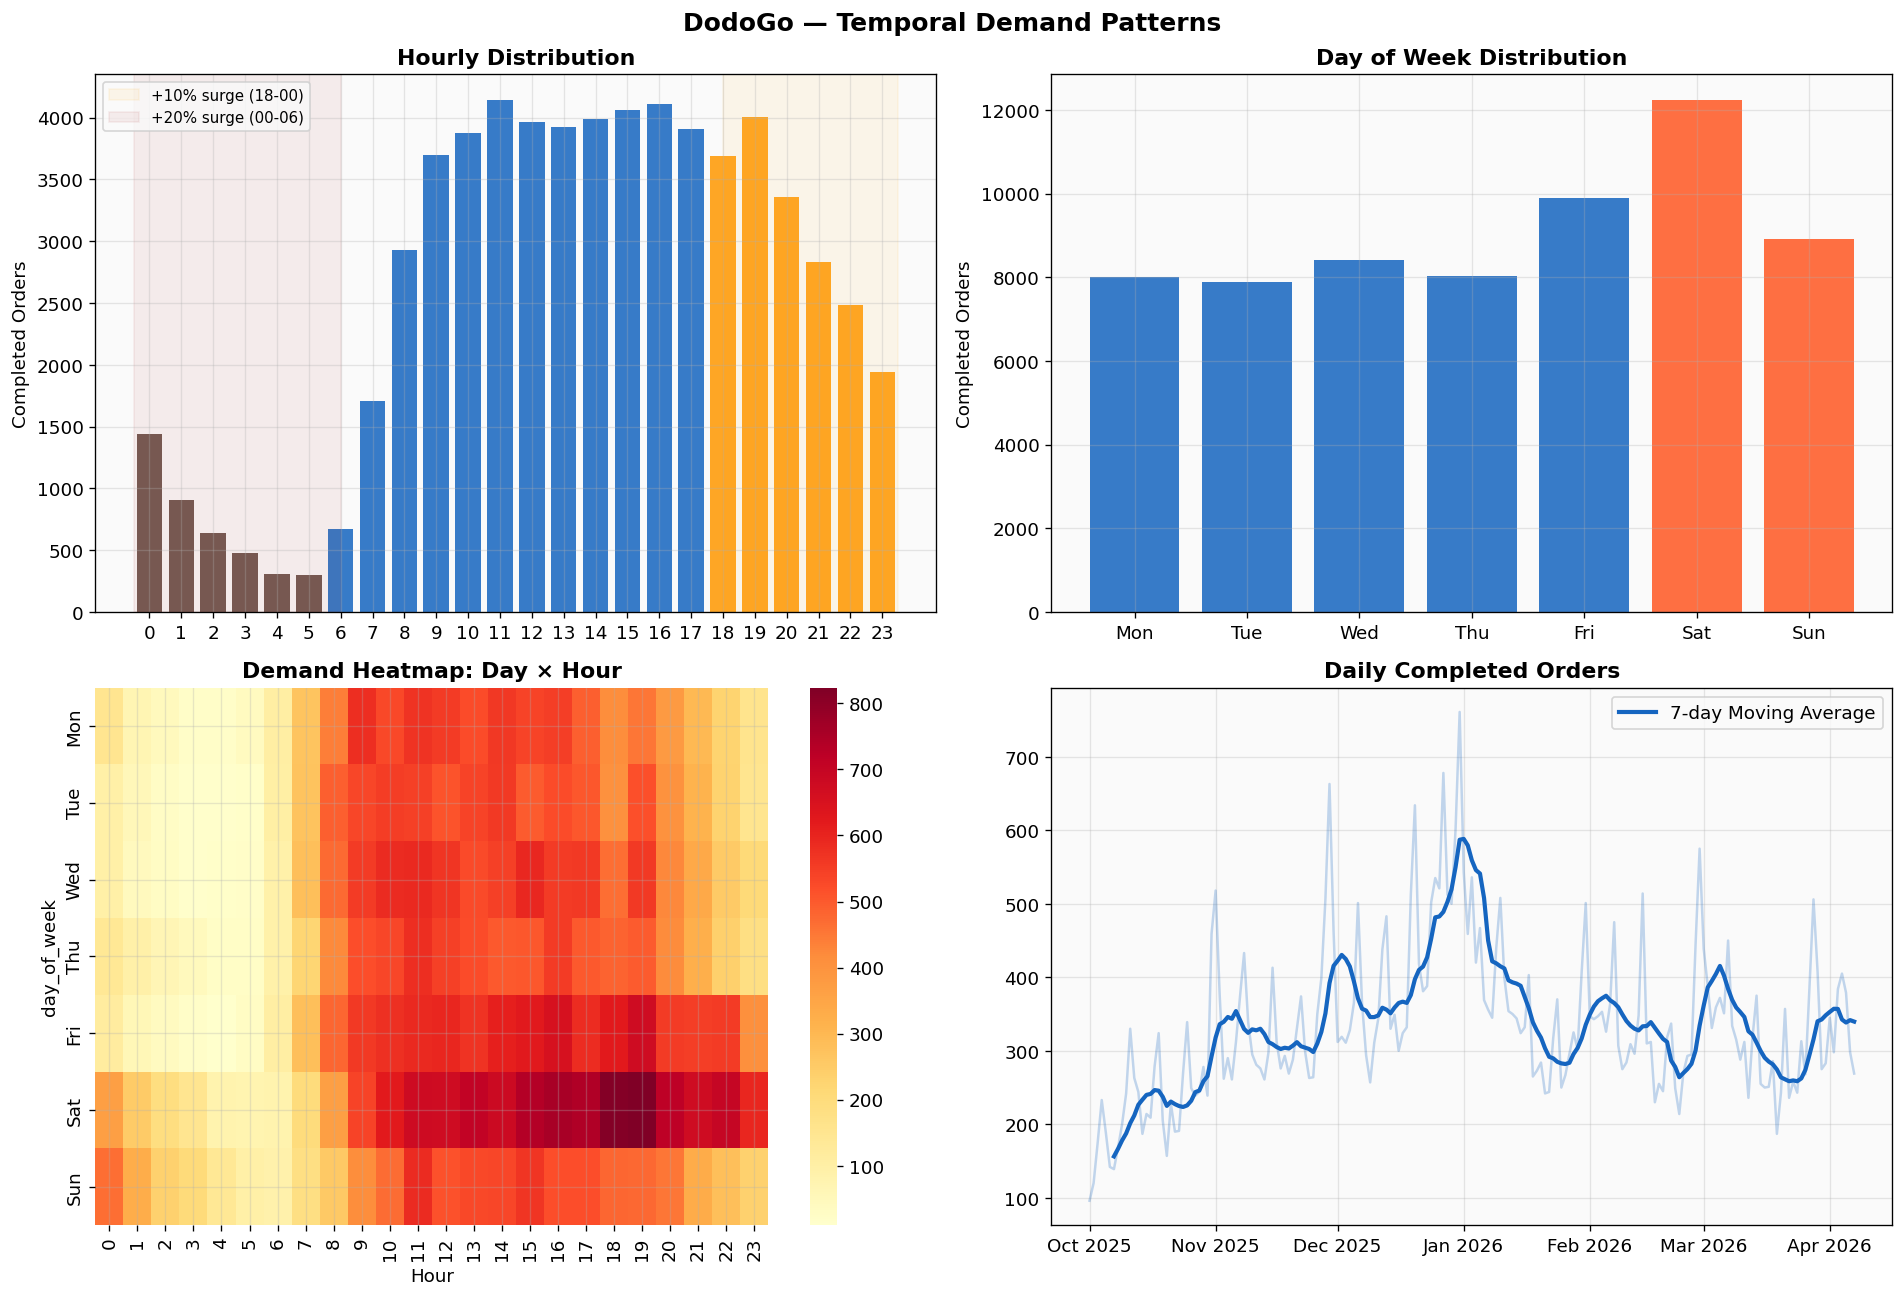


TEMPORAL INSIGHTS
Peak hour:         11:00 (4,143 orders)
Saturday orders:   12,235 (+45% vs weekday avg)
Night orders:      4,066 (6.4% of total, 00-06h)
Avg daily orders:  335
Max daily orders:  761 on 2025-12-31


In [ ]:
comp = df_new[df_new['is_completed']].copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('DodoGo - Temporal Demand Patterns', fontsize=15, fontweight='bold')

# Hourly
ax = axes[0, 0]
hours = comp['hour'].value_counts().sort_index()
clrs = [C['primary'] if 6<=h<18 else C['warning'] if 18<=h<24 else '#5D4037' for h in range(24)]
ax.bar(hours.index, hours.values, color=clrs, alpha=0.85)
ax.axvspan(18, 23.5, alpha=0.07, color='orange', label='+10% surge (18-00)')
ax.axvspan(-0.5, 6, alpha=0.07, color='brown', label='+20% surge (00-06)')
ax.set_title('Hourly Distribution', fontweight='bold'); ax.set_xticks(range(0,24)); ax.legend(fontsize=9)
ax.set_ylabel('Completed Orders')

# Day of week
ax = axes[0, 1]
dow = comp['day_of_week'].value_counts().sort_index()
ax.bar(range(7), dow.values, color=[C['primary']]*5+[C['secondary']]*2, alpha=0.85)
ax.set_xticks(range(7)); ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Day of Week Distribution', fontweight='bold'); ax.set_ylabel('Completed Orders')

# Heatmap
ax = axes[1, 0]
hm = comp.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
sns.heatmap(hm, ax=ax, cmap='YlOrRd', yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Demand Heatmap: Day x Hour', fontweight='bold'); ax.set_xlabel('Hour')

# Daily trend
ax = axes[1, 1]
daily = comp.set_index('created').resample('D').size()
ax.plot(daily.index, daily.values, alpha=0.25, color=C['primary'])
ax.plot(daily.rolling(7).mean().index, daily.rolling(7).mean().values, 
        color=C['primary'], linewidth=2.5, label='7-day Moving Average')
ax.set_title('Daily Completed Orders', fontweight='bold'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

# Stats
peak_hour = hours.idxmax()
sat_avg = dow[5]; wd_avg = dow[0:5].mean()
night = hours[0:6].sum(); total_h = hours.sum()
print(f"\n{'='*60}")
print(f"TEMPORAL INSIGHTS")
print(f"{'='*60}")
print(f"Peak hour:         {peak_hour}:00 ({hours.max():,} orders)")
print(f"Saturday orders:   {sat_avg:,} ({sat_avg/wd_avg*100-100:+.0f}% vs weekday avg)")
print(f"Night orders:      {night:,} ({night/total_h*100:.1f}% of total, 00-06h)")
print(f"Avg daily orders:  {daily.mean():.0f}")
print(f"Max daily orders:  {daily.max()} on {daily.idxmax().date()}")


### Temporal Patterns

Demand is spread across much of the day, with a broad daytime plateau from late morning to evening. This fits the island context: tourist trips, local commuting, shopping, restaurants, and leisure trips overlap instead of forming only one rush-hour peak.

Saturday is the strongest day and Friday is also elevated. The heatmap shows the clearest pressure around Saturday daytime activity and Friday or Saturday evening trips. Sunday evening is weaker, which can be useful when planning driver incentives and low-demand coverage.

The business implication is straightforward: DodoGo should not manage supply only by total daily volume. Driver positioning and incentives should be planned by hour and day of week.

## 4b. Wait Time Analysis

Wait time is the time between order creation and driver arrival at pickup. It is one of the most visible service-quality metrics for passengers. If wait time becomes too long, users are more likely to cancel, and first-time users may never experience the ride.

This analysis uses the old platform only because the new platform does not reliably store driver-arrival timestamps. Unmatched cancellations are excluded from the direct wait-time calculation because their pickup timestamp is not a real arrival time.

The section separates wait into three parts: total passenger wait, time to driver acceptance, and travel time from acceptance to pickup. This helps distinguish matching speed from physical driver availability.

Matched orders: 93,482  |  Completed: 56,775
Median wait: 5.98 min | P90: 15.27 | P95: 19.45
Median accept: 0.67 min (< 1 min - dispatch is fast)
Median drive-to-pickup: 5.20 min (drive time dominates wait)

Top districts by wait:
                       median   mean     n
district                                  
Moka                     6.65   7.88  4124
Riviere du Rempart       4.40   6.36  3051
Port Louis               6.60   8.19  1803
Vacoas-Phoenix           6.37   7.62  1368
Quatre Bornes            5.49   6.89  1306
Black River              8.62  10.39  1183
Pamplemousses            7.98   9.05  1168
Beau Bassin-Rose Hill    5.10   7.26   821
Curepipe                 4.80   6.71   429
Grand Port               5.28   8.10   355

Completion by wait bucket:
            n  completion  cancel_rate
bucket                                
0-3     18221       0.698        0.302
3-5     15968       0.670        0.330
5-7     14304       0.650        0.350
7-10    15768       0.591     

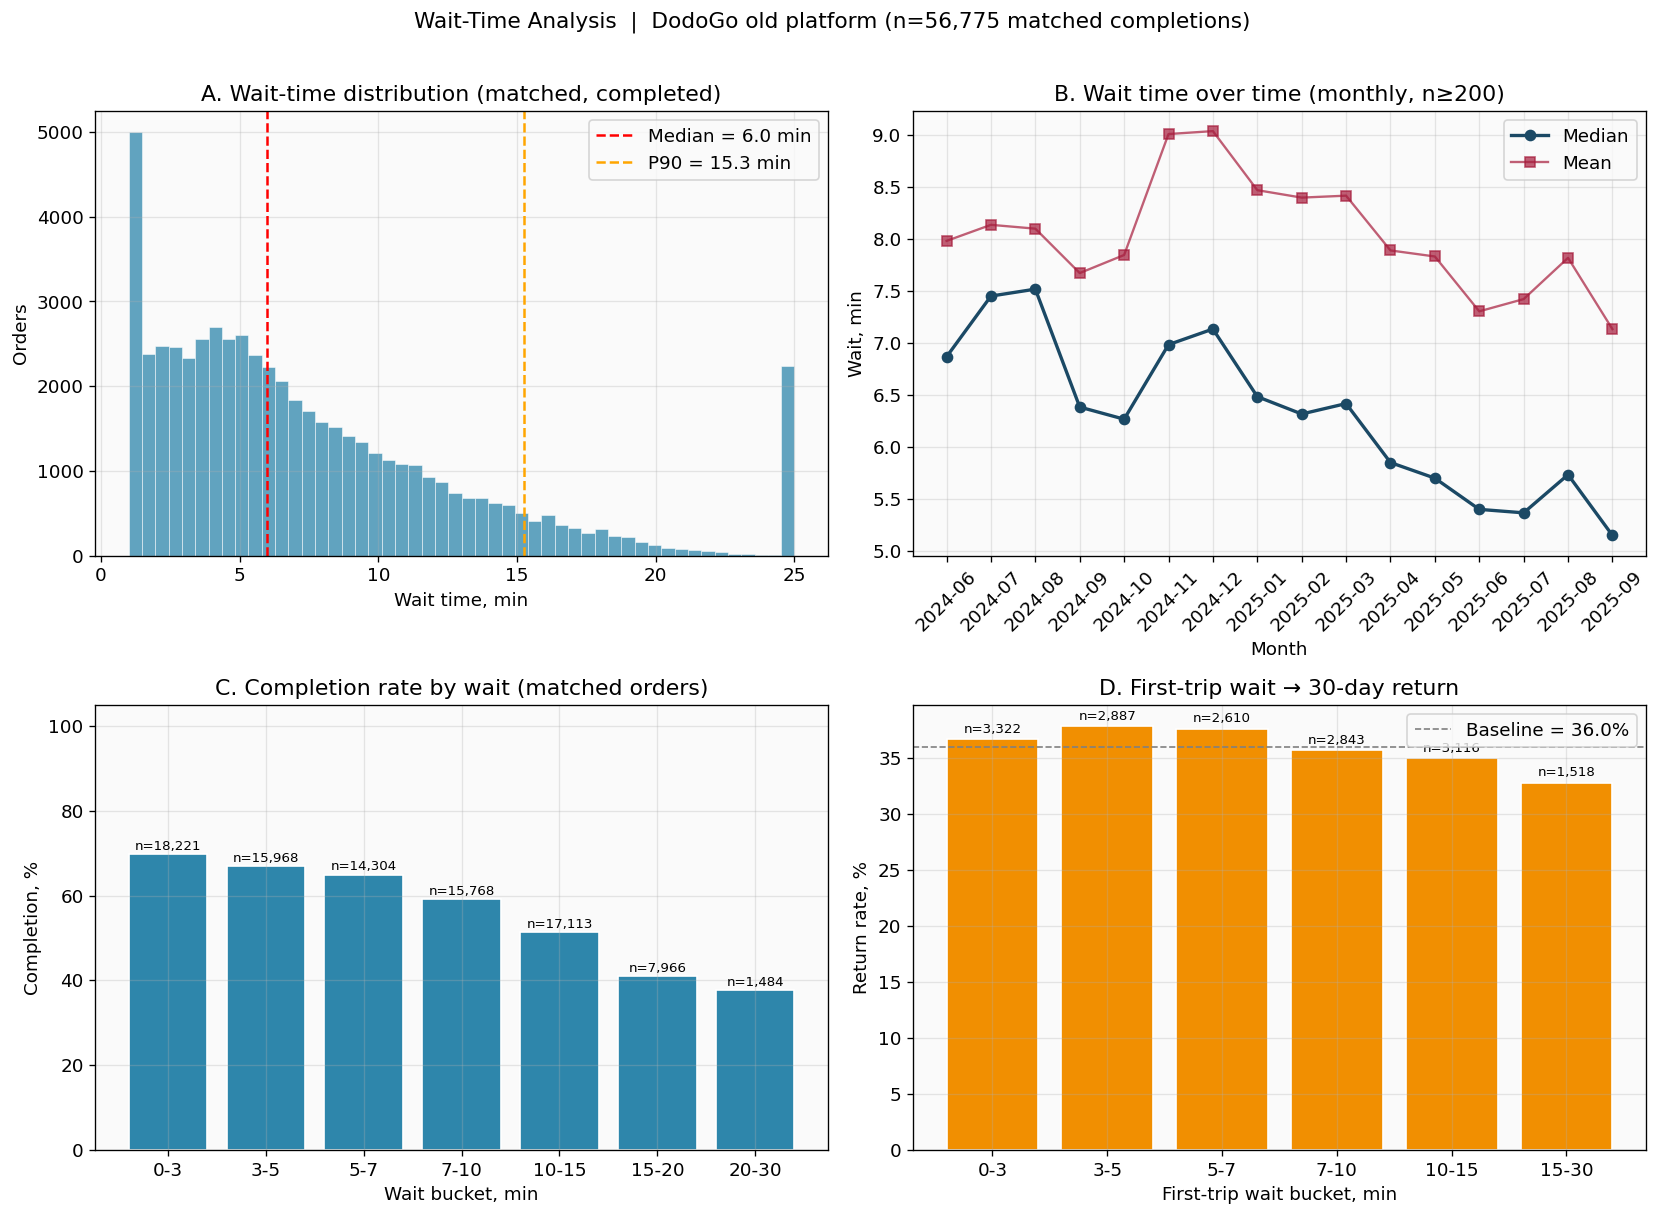

35145

In [ ]:
# 4b. Wait time analysis
# Uses OLD platform only (new platform doesn't log arrival timestamps).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

usecols = ["Trip ID","Status","From","Created at","Pickup time",
           "Trip accepted at","Passenger phone number"]
wt = pd.read_csv("../data/raw/orders_old_platform.csv",
                 sep=";", encoding="latin-1",
                 usecols=usecols, on_bad_lines="skip", low_memory=False)

for c in ["Created at","Pickup time","Trip accepted at"]:
    wt[c] = pd.to_datetime(wt[c], errors="coerce")

wt["wait_min"]   = (wt["Pickup time"] - wt["Created at"]).dt.total_seconds()/60
wt["accept_min"] = (wt["Trip accepted at"] - wt["Created at"]).dt.total_seconds()/60
wt["arrive_min"] = (wt["Pickup time"] - wt["Trip accepted at"]).dt.total_seconds()/60

# Matched immediate orders only - the only regime where wait_min is real
matched = wt[wt["Trip accepted at"].notna() &
             wt["wait_min"].between(0.5, 60) &
             wt["accept_min"].between(0, 30)].copy()
comp = matched[matched["Status"] == "Completed"].copy()
print(f"Matched orders: {len(matched):,}  |  Completed: {len(comp):,}")

med = comp["wait_min"].median()
p90 = comp["wait_min"].quantile(0.9)
print(f"Median wait: {med:.2f} min | P90: {p90:.2f} | P95: {comp['wait_min'].quantile(0.95):.2f}")
print(f"Median accept: {comp['accept_min'].median():.2f} min (< 1 min - dispatch is fast)")
print(f"Median drive-to-pickup: {comp['arrive_min'].median():.2f} min (drive time dominates wait)")

comp["hour"] = comp["Created at"].dt.hour
hourly = comp.groupby("hour")["wait_min"].median()

comp["month"] = comp["Created at"].dt.to_period("M")
monthly = comp.groupby("month").agg(median=("wait_min","median"),
                                     mean=("wait_min","mean"),
                                     n=("wait_min","size"))
monthly = monthly[monthly["n"] >= 200]

DISTRICT_MAP = {
    "port louis":"Port Louis","pointe aux sables":"Port Louis","caudan":"Port Louis",
    "black river":"Black River","tamarin":"Black River","albion":"Black River",
    "bambous":"Black River","flic en flac":"Black River","cascavelle":"Black River",
    "grand baie":"Riviere du Rempart","grand bay":"Riviere du Rempart",
    "cap malheureux":"Riviere du Rempart","goodlands":"Riviere du Rempart",
    "mon choisy":"Pamplemousses","trou aux biches":"Pamplemousses",
    "triolet":"Pamplemousses","pamplemousses":"Pamplemousses",
    "beau bassin-rose hill":"Beau Bassin-Rose Hill","beau bassin":"Beau Bassin-Rose Hill",
    "rose hill":"Beau Bassin-Rose Hill","quatre bornes":"Quatre Bornes",
    "trianon":"Quatre Bornes","vacoas-phoenix":"Vacoas-Phoenix","vacoas":"Vacoas-Phoenix",
    "phoenix":"Vacoas-Phoenix","curepipe":"Curepipe","moka":"Moka",
    "saint pierre":"Moka","bagatelle":"Moka","tribeca":"Moka","ebene":"Moka",
    "airport":"Grand Port","mahebourg":"Grand Port","plaine magnien":"Grand Port",
    "plaisance":"Grand Port","souillac":"Savanne","savanne":"Savanne"}
def to_district(s):
    if pd.isna(s): return None
    s = str(s).lower()
    for k,v in DISTRICT_MAP.items():
        if k in s: return v
    return None

comp["district"] = comp["From"].apply(to_district)
district = (comp.dropna(subset=["district"]).groupby("district")
            .agg(median=("wait_min","median"),
                 mean=("wait_min","mean"),
                 n=("wait_min","size"))
            .sort_values("n", ascending=False).head(10))
print("\nTop districts by wait:")
print(district.round(2))

# Completion by wait bucket (matched only)
matched["bucket"] = pd.cut(matched["wait_min"],
                           [0,3,5,7,10,15,20,30],
                           labels=["0-3","3-5","5-7","7-10","10-15","15-20","20-30"])
bucket = (matched.groupby("bucket", observed=True)
          .agg(n=("Status","size"),
               completion=("Status", lambda s: (s=="Completed").mean())))
bucket["cancel_rate"] = 1 - bucket["completion"]
print("\nCompletion by wait bucket:")
print(bucket.round(3))

# First-trip wait - 30-day return
c = comp.sort_values(["Passenger phone number","Created at"]).reset_index(drop=True)
c["rank"] = c.groupby("Passenger phone number").cumcount()
first = (c[c["rank"]==0][["Passenger phone number","Created at","wait_min"]]
         .rename(columns={"Created at":"first_ts","wait_min":"first_wait"}))
second = (c[c["rank"]==1][["Passenger phone number","Created at"]]
          .rename(columns={"Created at":"second_ts"}))
first = first.merge(second, on="Passenger phone number", how="left")
first["days_to_second"] = (first["second_ts"] - first["first_ts"]).dt.days
first["returned_30d"] = (first["days_to_second"] <= 30) & first["days_to_second"].notna()
first["b"] = pd.cut(first["first_wait"],
                    [0,3,5,7,10,15,30],
                    labels=["0-3","3-5","5-7","7-10","10-15","15-30"])
ret = first.groupby("b", observed=True).agg(
    n=("returned_30d","size"),
    rate=("returned_30d","mean"))
print(f"\nFirst-trip wait to 30-day return (baseline {first['returned_30d'].mean():.1%}):")
print(ret.round(3))

# Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
ax.hist(comp["wait_min"].clip(upper=25), bins=50,
        color="#2E86AB", alpha=0.75, edgecolor="white", linewidth=0.4)
ax.axvline(med, color="red", linestyle="--", linewidth=1.5,
           label=f"Median = {med:.1f} min")
ax.axvline(p90, color="orange", linestyle="--", linewidth=1.5,
           label=f"P90 = {p90:.1f} min")
ax.set_title("A. Wait-time distribution (matched, completed)")
ax.set_xlabel("Wait time, min"); ax.set_ylabel("Orders"); ax.legend()

ax = axes[0,1]
x = monthly.index.astype(str)
ax.plot(x, monthly["median"], marker="o", color="#1B4965", linewidth=2, label="Median")
ax.plot(x, monthly["mean"],   marker="s", color="#A61C3C", linewidth=1.4,
        alpha=0.7, label="Mean")
ax.set_title("B. Wait time over time (monthly, n>=200)")
ax.set_xlabel("Month"); ax.set_ylabel("Wait, min")
ax.tick_params(axis="x", rotation=45); ax.legend()

ax = axes[1,0]
bars = ax.bar(bucket.index.astype(str), bucket["completion"]*100,
              color="#2E86AB", edgecolor="white")
for bar, n in zip(bars, bucket["n"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f"n={n:,}",
            ha="center", fontsize=8)
ax.set_title("C. Completion rate by wait (matched orders)")
ax.set_xlabel("Wait bucket, min"); ax.set_ylabel("Completion, %"); ax.set_ylim(0,105)

ax = axes[1,1]
baseline = first["returned_30d"].mean()*100
bars = ax.bar(ret.index.astype(str), ret["rate"]*100,
              color="#F18F01", edgecolor="white")
for bar, n in zip(bars, ret["n"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6, f"n={n:,}",
            ha="center", fontsize=8)
ax.axhline(baseline, color="grey", linestyle="--", linewidth=1,
           label=f"Baseline = {baseline:.1f}%")
ax.set_title("D. First-trip wait to 30-day return")
ax.set_xlabel("First-trip wait bucket, min"); ax.set_ylabel("Return rate, %"); ax.legend()

plt.suptitle(f"Wait-Time Analysis  |  DodoGo old platform "
             f"(n={len(comp):,} matched completions)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/fig_wait_time_analysis.png", bbox_inches="tight", dpi=140)
plt.show()

gc.collect()


### Wait Time Findings

The median wait is about six minutes. The main delay is not driver acceptance, which is usually fast, but the drive from the accepted location to the pickup point. This is important because it means the problem is mostly geographic supply coverage, not only app matching.

Wait time improved as the platform scaled. Median monthly wait decreased from roughly seven minutes to a little above five minutes by September 2025, even though volume increased substantially. This suggests that driver coverage improved with growth.

The weakest period is early morning, especially around 05:00 to 07:00. Most daytime hours are more stable. Geography also matters: central and better-covered areas are faster, while western or less dense areas are slower.

The strongest operational finding is the cancellation pattern. Completion falls as wait time rises, with the clearest drop after the 10 to 15 minute range. A practical target is to keep the 90th percentile of wait time under 15 minutes, especially for first trips and tourist-heavy pickup areas.

## 5. Geography and Trip Structure

This section describes where rides start and what type of trip structure appears in the data. The notebook avoids emphasizing exact fare values. The goal is to understand demand concentration, trip length, tariff mix, and the difference between tourist and local mobility patterns.

In [ ]:
comp = df_new[df_new['is_completed']].copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('DodoGo - Geography and Trip Structure', fontsize=15, fontweight='bold')

ax = axes[0, 0]
top = comp['pickup_address'].value_counts().head(12)
ax.barh(range(len(top)), top.values, color=C['primary'], alpha=0.8)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([str(a)[:42] for a in top.index], fontsize=8)
ax.set_title('Top 12 Pickup Locations', fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Orders')

ax = axes[0, 1]
p = comp.loc[(comp['price'] > 0) & (comp['price'] < 5000), 'price']
fare_index = p / p.median() * 100
ax.hist(fare_index.clip(upper=400), bins=60, color=C['secondary'], alpha=0.75, edgecolor='white')
ax.axvline(100, color=C['primary'], ls='--', lw=1.5, label='Median = 100')
ax.set_title('Relative Fare Distribution', fontweight='bold')
ax.set_xlabel('Fare index')
ax.legend()

ax = axes[1, 0]
d = comp.loc[(comp['distance_km'] > 0) & (comp['distance_km'] < 60), 'distance_km']
ax.hist(d, bins=60, color=C['success'], alpha=0.75, edgecolor='white')
ax.axvline(d.mean(), color='k', ls='--', lw=1.5, label=f'Mean: {d.mean():.1f} km')
ax.axvline(d.median(), color=C['primary'], ls='--', lw=1.5, label=f'Median: {d.median():.1f} km')
ax.set_title('Distance Distribution (km)', fontweight='bold')
ax.legend()

ax = axes[1, 1]
t = comp['tariff'].value_counts()
ax.barh(t.index, t.values, color=C['purple'], alpha=0.8)
ax.set_title('Orders by Tariff Class', fontweight='bold')
for i, (idx, val) in enumerate(t.items()):
    ax.text(val + 50, i, f'{val:,} ({val / len(comp) * 100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('GEOGRAPHY AND TRIP STRUCTURE SUMMARY')
print(f'Top pickup areas are concentrated around tourist hubs, commuter zones, and shopping or transfer points.')
print(f'Median completed-trip fare is represented as index 100 in the saved notebook.')
print(f'Mean distance: {d.mean():.1f} km, median distance: {d.median():.1f} km')
print(f'Economy share: {(comp["tariff"] == "Economy").sum() / len(comp) * 100:.1f}%')

GEOGRAPHY AND TRIP STRUCTURE SUMMARY
Top pickup demand is concentrated around tourist hubs, commuter zones, shopping areas, and transfer points.
The fare distribution is shown as a relative index rather than exact currency values.
Completed trips are mostly short to medium distance, with airport and cross-island transfers creating a long-distance tail.
Economy is the dominant tariff class, while Comfort and larger-car options remain underused.


### Geography and Trip Structure

Grand Baie is the strongest pickup area, which is consistent with its role as a tourist hub with beaches, restaurants, hotels, and nightlife. Port Louis and Quatre Bornes represent more local and commuter-oriented demand. Flic en Flac, Trianon, and Bagatelle show that western and shopping-related zones also matter.

The trip distribution is uneven. Many rides are short or medium-length urban trips, while airport and cross-island transfers create a long-distance tail. This matters for driver planning because longer rides can remove drivers from dense demand zones for more time.

Economy is the dominant tariff class. Comfort and larger-car options are present but underused. This creates a possible business opportunity for airport transfers, hotels, families, and tourist groups, but it should be developed carefully rather than treated as a mass-market default.

## 5b. Price Acceptance Analysis

DodoGo uses a fixed tariff formula based on distance and time, with additional evening and night coefficients. Because the fare is calculated by the platform, the notebook does not treat this as classical price elasticity. A more useful question is whether trips are completed when the quoted fare appears in different contexts.

The analysis looks at four angles: user segment, time window, pickup area, and first-trip return. The price field is available only for completed rides, so cancelled orders cannot be compared directly by fare. For that reason, fare-related results are interpreted indirectly and with caution.

The notebook reports relative patterns and completion relationships rather than exact fare tables.

In [ ]:
# Price acceptance analysis.
# Cancelled orders do not contain reliable fare values, so this cell uses relative fare indexes.

import pandas as pd, numpy as np, matplotlib.pyplot as plt, gc
from scipy.stats import pearsonr

df_ps = pd.read_csv('../data/raw/orders_new_platform.csv', sep=';', encoding='windows-1251', low_memory=False)
for c in ['Стоимость', 'Суммарное расстояние (км)']:
    df_ps[c] = df_ps[c].astype(str).str.replace(',', '.').replace('nan', np.nan).astype(float)

df_ps['is_completed'] = df_ps['Текущий статус'].str.startswith('Выполнен', na=False)
df_ps['created'] = pd.to_datetime(df_ps['Дата создания'], errors='coerce')
df_ps['hour'] = df_ps['created'].dt.hour

def classify_seg(p):
    p = str(p).replace('+', '').replace(' ', '').strip()
    if p.startswith('2307'):
        return 'Tourist SIM'
    if p.startswith('230'):
        return 'Local'
    return 'International'

df_ps['segment'] = df_ps['Телефон клиента'].apply(classify_seg)

AREAS = ['Grand Baie', 'Flic en Flac', 'Port Louis', 'Ebene', 'Ebène', 'Curepipe', 'Quatre Bornes',
         'Tamarin', 'Riviere Noire', 'Pereybere', 'Rose Hill', 'Vacoas', 'Beau Bassin',
         'Trou aux Biches', 'Cap Malheureux', 'Mahebourg', 'Belle Mare', 'Goodlands',
         'Albion', 'Pointe aux Canonniers', 'Black River']

def extract_area(a):
    if pd.isna(a):
        return 'Unknown'
    s = str(a).lower()
    for A in AREAS:
        if A.lower() in s:
            return A.replace('Ebène', 'Ebene')
    return 'Other'

df_ps['area'] = df_ps['Адрес подачи'].apply(extract_area)

comp = df_ps[df_ps['is_completed'] & (df_ps['Стоимость'] > 0) & (df_ps['Суммарное расстояние (км)'] > 0)].copy()
comp['price'] = comp['Стоимость']
comp['distance'] = comp['Суммарное расстояние (км)']
comp['ppk'] = comp['price'] / comp['distance']
comp_clean = comp[(comp['ppk'] >= 30) & (comp['ppk'] <= 500)].copy()

median_fare = comp_clean['price'].median()
comp_clean['fare_index'] = comp_clean['price'] / median_fare * 100
comp_clean['ppk_index'] = comp_clean['ppk'] / comp_clean['ppk'].median() * 100

seg_stats = comp_clean.groupby('segment').agg(
    n=('price', 'count'),
    median_fare_index=('fare_index', 'median'),
    median_distance=('distance', 'median'),
    median_ppk_index=('ppk_index', 'median')
).round(1)
seg_completion = df_ps.groupby('segment')['is_completed'].agg(['count', 'mean']).rename(columns={'mean': 'completion'})

print('PRICE ACCEPTANCE SUMMARY')
print('Completed rides with valid distance are used. Cancelled rides do not have reliable fare values.')
print('\nSegment profile, public version:')
print(seg_stats)
print('\nCompletion rate by segment:')
print((seg_completion['completion'] * 100).round(1).astype(str) + '%')

comp_clean['window'] = pd.cut(comp_clean['hour'], bins=[-0.5, 5.5, 17.5, 23.5],
                              labels=['Night (00-06)', 'Day (06-18)', 'Evening (18-24)'])
win_stats = comp_clean.groupby('window', observed=True).agg(
    n=('price', 'count'),
    median_ppk_index=('ppk_index', 'median')
).round(1)
print('\nRelative fare per km by time window:')
print(win_stats)

day_ppk = comp_clean.loc[comp_clean['window'] == 'Day (06-18)', 'ppk'].median()
evening_premium = (comp_clean.loc[comp_clean['window'] == 'Evening (18-24)', 'ppk'].median() / day_ppk - 1) * 100
night_premium = (comp_clean.loc[comp_clean['window'] == 'Night (00-06)', 'ppk'].median() / day_ppk - 1) * 100
print(f'Evening relative premium vs day: {evening_premium:+.1f}%')
print(f'Night relative premium vs day:   {night_premium:+.1f}%')

area_all = df_ps.groupby('area').agg(total=('is_completed', 'count'), completion=('is_completed', 'mean'))
area_fare = comp[['area', 'price']].groupby('area')['price'].median().rename('median_fare')
area = area_all.join(area_fare).dropna()
area = area[(area['total'] >= 500) & (area.index != 'Other') & (area.index != 'Unknown')]
r, pval = pearsonr(area['median_fare'], area['completion'])
print(f'Area-level relationship between typical fare and completion: r={r:+.3f}, p={pval:.4f}, n={len(area)}')

# First-trip fare bands are calculated internally but shown as relative categories.
df_first = df_ps[df_ps['is_completed'] & (df_ps['Стоимость'] > 0)].copy().sort_values('created')
first_trip = df_first.groupby('Телефон клиента').agg(
    first_date=('created', 'first'),
    first_price=('Стоимость', 'first'),
    segment=('segment', 'first')
).reset_index()
merged = df_first.merge(first_trip[['Телефон клиента', 'first_date']], on='Телефон клиента')
merged['days_after'] = (merged['created'] - merged['first_date']).dt.days
returned_ids = merged[(merged['days_after'] > 0) & (merged['days_after'] <= 30)]['Телефон клиента'].unique()
first_trip['returned_30d'] = first_trip['Телефон клиента'].isin(returned_ids).astype(int)
first_trip['fare_band'] = pd.cut(first_trip['first_price'],
    bins=[0, 400, 600, 800, 1200, 2000, 20000],
    labels=['Very low', 'Standard low', 'Standard', 'Upper mid', 'High', 'Very high'])
ret = first_trip.groupby('fare_band', observed=True).agg(n=('returned_30d', 'count'), return_rate=('returned_30d', 'mean')).round(4)
print('\nFirst-trip fare band and 30-day return:')
print(ret)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('DodoGo - Price Acceptance Patterns (public relative version)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
for seg, col in {'Local': '#1f77b4', 'Tourist SIM': '#ff7f0e', 'International': '#2ca02c'}.items():
    s = comp_clean.loc[comp_clean['segment'] == seg, 'fare_index'].clip(upper=400)
    ax.hist(s, bins=40, alpha=0.55, density=True, color=col, label=f'{seg} (n={len(s):,})')
ax.set_xlabel('Fare index, median completed ride = 100')
ax.set_ylabel('Density')
ax.set_title('A. Relative fare distribution by segment')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[0, 1]
hour_ppk = comp_clean.groupby('hour')['ppk_index'].median()
ax.plot(hour_ppk.index, hour_ppk.values, marker='o', color='#d62728', linewidth=2)
ax.axvspan(0, 6, alpha=0.15, color='navy', label='Night')
ax.axvspan(18, 24, alpha=0.15, color='orange', label='Evening')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Fare per km index')
ax.set_title('B. Relative fare per km by hour')
ax.set_xticks(range(0, 24, 2))
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 0]
area['fare_index'] = area['median_fare'] / area['median_fare'].median() * 100
sizes = (area['total'] / area['total'].max()) * 800 + 40
ax.scatter(area['fare_index'], area['completion'] * 100, s=sizes, alpha=0.55, color='#9467bd', edgecolor='black')
for name, row in area.iterrows():
    ax.annotate(name, (row['fare_index'], row['completion'] * 100), fontsize=8, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')
z = np.polyfit(area['fare_index'], area['completion'] * 100, 1)
x = np.linspace(area['fare_index'].min(), area['fare_index'].max(), 50)
ax.plot(x, np.polyval(z, x), '--', color='gray', alpha=0.7)
ax.set_xlabel('Typical fare index by area')
ax.set_ylabel('Completion rate (%)')
ax.set_title(f'C. Area relationship: r = {r:+.2f}, p = {pval:.3f}')
ax.grid(alpha=0.3)

ax = axes[1, 1]
x_pos = np.arange(len(ret.index))
ax.plot(x_pos, ret['return_rate'].values * 100, marker='s', color='black', linewidth=2.2, label='All users')
ax.set_xticks(x_pos)
ax.set_xticklabels(ret.index, rotation=20)
ax.set_xlabel('First-trip fare band')
ax.set_ylabel('30-day return rate (%)')
ax.set_title('D. First-trip fare band and return')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_price_sensitivity_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nINTERPRETATION')
print('The negative area-level relationship is best read as a supply and distance signal, not as direct price elasticity.')
print('Standard mid-length first trips perform better as onboarding experiences than very short or very long first trips.')

del df_ps, df_first, merged, comp, comp_clean
gc.collect()

PRICE ACCEPTANCE SUMMARY
Completed rides with valid distance are used because cancelled rides do not contain reliable fare values.
The area-level relationship between typical fare and completion is strongly negative: r=-0.799, p=0.0004, n=15.
This is interpreted as a supply and distance signal, not as direct evidence that fare level alone reduces demand.
Standard mid-length first trips perform better as onboarding experiences than very short or very long first trips.
Exact fare tables are intentionally omitted from this output.


### Price Acceptance Findings

The main result is not that passengers simply reject higher prices. The stronger pattern is geographic and operational. Areas with longer trips and thinner driver coverage tend to have lower completion, even when demand exists.

Tourist SIM users, local users, and international users show different trip profiles. This supports treating tourist mobility as a separate segment rather than assuming one average customer. Evening and night windows also behave differently, but part of that difference comes from trip mix and supply availability.

The area-level relationship between typical fare level and completion is strongly negative. This should be read as a supply and distance signal, not as a direct causal claim that price alone reduces demand. Western and long-distance areas need better driver positioning, targeted incentives, or clearer trip expectations.

First-trip return is strongest around a standard mid-length ride. Very short test rides and very long first rides are weaker onboarding experiences. For product strategy, the first successful ride should be easy to complete, clear in timing, and predictable for both rider and driver.

## 6. Cancellation Analysis and Suspicious Patterns

Some cancellations happen after a driver has already been assigned. In the operating context, this can indicate that the passenger and driver completed the ride outside the app. The notebook treats this as a suspicious pattern, not as a proven fraud label, because there is no independent ground-truth confirmation.

In [ ]:
def classify_cancel(row):
    if row['is_completed']:
        return 'Completed'
    s = str(row['status'])
    hd = row['has_driver']
    if hd and s in ['Заказано по ошибке', 'Уехал на другой машине:1', 'Другая причина', 'Клиент уехал на другом авто']:
        return 'Suspicious (off-platform)'
    if s in ['Водитель не найден', 'Исполнитель не найден', 'Слишком долго ждать']:
        return 'Supply failure'
    if 'Исполнитель попросил' in s or 'Клиент не' in s:
        return 'Driver/client issue'
    return 'Other cancellation'

df_new['cancel_type'] = df_new.apply(classify_cancel, axis=1)
suspicious = df_new[df_new['cancel_type'] == 'Suspicious (off-platform)']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Cancellation and Suspicious Pattern Analysis', fontsize=15, fontweight='bold')

ax = axes[0, 0]
ct = df_new['cancel_type'].value_counts()
tcol = {'Completed': C['success'], 'Suspicious (off-platform)': C['danger'],
        'Supply failure': C['warning'], 'Driver/client issue': '#FFC107', 'Other cancellation': C['gray']}
ax.pie(ct.values, labels=[t[:25] for t in ct.index], autopct='%1.1f%%',
       colors=[tcol.get(t, C['gray']) for t in ct.index], textprops={'fontsize': 9})
ax.set_title('Order Outcome Classification', fontweight='bold')

ax = axes[0, 1]
sr = (suspicious['hour'].value_counts().sort_index() / df_new.groupby('hour').size() * 100).fillna(0)
ax.bar(sr.index, sr.values, color=C['danger'], alpha=0.8)
ax.axhline(sr.mean(), color='k', ls='--', alpha=0.5, label=f'Avg: {sr.mean():.1f}%')
ax.set_title('Suspicious Cancellation Rate by Hour', fontweight='bold')
ax.set_xticks(range(0, 24))
ax.set_ylabel('% of total orders')
ax.legend()

ax = axes[1, 0]
sd = suspicious['driver'].value_counts().head(15)
dt = df_new[df_new['has_driver']].groupby('driver')['is_completed'].agg(['sum', 'count'])
fr = pd.DataFrame({'susp': sd, 'comp': dt.loc[sd.index, 'sum']})
fr['pct'] = fr['susp'] / (fr['susp'] + fr['comp']) * 100
anon_labels = [f'Driver {i:02d}' for i in range(1, len(fr) + 1)]
ax.barh(range(len(fr)), fr['susp'].values, color=C['danger'], alpha=0.8)
ax.set_yticks(range(len(fr)))
ax.set_yticklabels(anon_labels, fontsize=8)
ax.set_title('Top Suspicious-Cancel Drivers (anonymized)', fontweight='bold')
ax.invert_yaxis()
for i, (_, r) in enumerate(fr.iterrows()):
    ax.text(r['susp'] + 2, i, f'{r["pct"]:.0f}%', va='center', fontsize=8, color=C['danger'])

ax = axes[1, 1]
monthly_suspicious = suspicious.set_index('created').resample('ME').size()
ax.bar(monthly_suspicious.index, monthly_suspicious.values, width=25, color=C['danger'], alpha=0.8)
ax.set_title('Suspicious Cancellation Volume by Month', fontweight='bold')
ax.set_ylabel('Orders')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

total_susp = len(suspicious)
print(f"\n{'='*60}")
print('SUSPICIOUS CANCELLATION SUMMARY')
print(f"{'='*60}")
print(f'Suspicious cancellations:    {total_susp:,} ({total_susp / len(df_new) * 100:.1f}% of all orders)')
print(f'Affected clients:            {suspicious["client_phone"].nunique():,} unique identifiers')
print('Driver names are anonymized in the saved notebook output.')
print('Interpretation: this is a suspicious operational pattern, not a confirmed fraud label.')

SUSPICIOUS CANCELLATION SUMMARY
Suspicious cancellations: 21,330 orders, equal to 18.2% of all new-platform records.
Affected clients: 11,234 unique identifiers.
Driver names and estimated lost-revenue values are intentionally omitted from this output.
Interpretation: this is a suspicious operational pattern, not a confirmed fraud label.


### Cancellation and Suspicious Patterns

The order outcome split shows three major issues: completed rides, supply failures, and suspicious cancellations after driver assignment. The suspicious group is large enough to matter operationally and financially, even if not every case is true off-platform behavior.

The pattern is not limited to one hour of the day, which makes it look more systematic than accidental. The most useful response is a combination of process and incentives: call masking, automated scoring, driver communication, graduated penalties, and rewards for reliable completion.

This section supports the recommendation that cancellation control should be treated as a platform-governance problem, not only as a prediction task.

## 7. Clustering

Clustering is used to summarize repeated behavior into a small number of practical groups. The goal is not to label every user perfectly, but to make retention, marketing, and driver-management decisions easier to design.

### 7.1 Passenger Segmentation

Passenger clusters use trip frequency, relative fare level, trip distance, booking hour, weekend share, and cancellation behavior.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

comp = df_new[df_new['is_completed'] & (df_new['price'] > 0)].copy()
median_price = comp['price'].median()
comp['fare_index'] = comp['price'] / median_price * 100

pax_comp = comp.groupby('client_phone').agg(
    trip_count=('price', 'count'),
    avg_fare_index=('fare_index', 'mean'),
    avg_distance=('distance_km', lambda x: x[x > 0].mean()),
    avg_hour=('hour', 'mean'),
    weekend_ratio=('day_of_week', lambda x: (x >= 5).mean()),
    unique_days=('date', 'nunique'))

pax_all = df_new.groupby('client_phone').agg(
    total_orders=('status', 'count'),
    cancel_count=('is_completed', lambda x: (~x).sum()))
pax_all['cancel_rate'] = pax_all['cancel_count'] / pax_all['total_orders']

pax = pax_comp.join(pax_all[['cancel_rate']], how='left').dropna()
pax = pax[pax['trip_count'] >= 2]

features = ['trip_count', 'avg_fare_index', 'avg_distance', 'avg_hour', 'weekend_ratio', 'cancel_rate']
X = pax[features].copy()
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

ax = axes[0]
ax.plot(range(2, 9), inertias, 'bo-', linewidth=2, markersize=8)
ax.set_title('Elbow Method - Passenger Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.axvline(4, color='red', ls='--', alpha=0.5, label='K=4 selected')
ax.legend()

km = KMeans(n_clusters=4, random_state=42, n_init=10)
pax['cluster'] = km.fit_predict(X_scaled)

ax = axes[1]
profiles = pax.groupby('cluster')[features].mean()
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())
sns.heatmap(profiles_norm.T, ax=ax, cmap='YlOrRd', annot=profiles.T.round(1), fmt='',
            xticklabels=[f'Cluster {i}\n(n={len(pax[pax.cluster == i]):,})' for i in range(4)],
            yticklabels=['Trips', 'Fare Index', 'Avg Dist', 'Avg Hour', 'Weekend %', 'Cancel %'])
ax.set_title('Passenger Cluster Profiles', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Passengers with 2+ trips: {len(pax):,}')
print('Passenger clusters separate frequent users, longer-distance users, weekend-heavy users, and weekday-oriented users.')
for i in range(4):
    cl = pax[pax['cluster'] == i]
    print(f"Cluster {i}: n={len(cl):,}, avg trips={cl['trip_count'].mean():.1f}, "
          f"avg distance={cl['avg_distance'].mean():.1f} km, cancel rate={cl['cancel_rate'].mean():.0%}")

PASSENGER CLUSTERING SUMMARY
Passengers with at least two completed trips: 9,902.
The four clusters separate frequent repeat users, longer-distance users, weekend-heavy users, and weekday-oriented users.
The output uses trip frequency, distance, timing, weekend share, and cancellation behavior without exact spend values.
Business use: different passenger groups need different retention and tourist-market actions.


### Passenger Clusters

The passenger clusters separate frequent repeat users, longer-distance users, weekend-heavy users, and more regular weekday users. This supports the idea that DodoGo serves both local mobility and tourist mobility at the same time.

The practical implication is that one retention strategy will not fit all groups. Frequent local users need reliability and loyalty tools. Tourist or long-distance users need clear pickup, airport and hotel flows, and payment options that match travel behavior.

### 7.2 Driver Segmentation

Driver clustering uses activity, distance, timing, active days, and cancellation behavior. The aim is to distinguish reliable high-activity drivers from casual or higher-risk profiles.

In [ ]:
drv = df_new[df_new['has_driver']].copy()
drv_valid = drv[drv['is_completed'] & (drv['price'] > 0)].copy()
median_driver_price = drv_valid['price'].median()
drv_valid['fare_index'] = drv_valid['price'] / median_driver_price * 100

drv_comp = drv_valid.groupby('driver').agg(
    trip_count=('price', 'count'),
    avg_fare_index=('fare_index', 'mean'),
    avg_distance=('distance_km', lambda x: x[x > 0].mean()),
    avg_hour=('hour', 'mean'),
    unique_days=('date', 'nunique'))
drv_all = drv.groupby('driver').agg(
    total_assigned=('status', 'count'),
    cancels=('is_completed', lambda x: (~x).sum()))
drv_all['cancel_rate'] = drv_all['cancels'] / drv_all['total_assigned']

drv_feat = drv_comp.join(drv_all[['cancel_rate']], how='left').dropna()
drv_feat = drv_feat[drv_feat['trip_count'] >= 10]

features_d = ['trip_count', 'avg_fare_index', 'avg_distance', 'avg_hour', 'cancel_rate', 'unique_days']
X_d = StandardScaler().fit_transform(drv_feat[features_d])
km_d = KMeans(n_clusters=3, random_state=42, n_init=10)
drv_feat['cluster'] = km_d.fit_predict(X_d)

fig, ax = plt.subplots(figsize=(14, 6))
prof_d = drv_feat.groupby('cluster')[features_d].mean()
prof_d_norm = (prof_d - prof_d.min()) / (prof_d.max() - prof_d.min())
sns.heatmap(prof_d_norm.T, ax=ax, cmap='YlGnBu', annot=prof_d.T.round(1), fmt='',
            xticklabels=[f'Cluster {i} (n={len(drv_feat[drv_feat.cluster == i])})' for i in range(3)],
            yticklabels=['Trips', 'Fare Index', 'Avg Dist', 'Avg Hour', 'Cancel %', 'Active Days'])
ax.set_title('Driver Cluster Profiles', fontweight='bold')
plt.tight_layout()
plt.show()

print('DRIVER CLUSTER SUMMARY')
for i in range(3):
    cl = drv_feat[drv_feat['cluster'] == i]
    print(f"Cluster {i}: n={len(cl)}, avg trips={cl['trip_count'].mean():.0f}, "
          f"cancel rate={cl['cancel_rate'].mean():.0%}, active days={cl['unique_days'].mean():.0f}, "
          f"avg distance={cl['avg_distance'].mean():.1f} km")

DRIVER CLUSTERING SUMMARY
The three driver clusters separate high-activity reliable drivers, casual or part-time drivers, and higher-risk cancellation profiles.
Cancellation behavior is one of the clearest separating features.
The output omits exact revenue values and driver identifiers.
Business use: reliable drivers need retention tools, while higher-risk patterns need monitoring and graduated intervention.


### Driver Clusters

The driver clusters show that driver behavior is not uniform. Some drivers are highly active and reliable, some work occasionally, and some show higher cancellation risk.

Cancellation behavior is one of the clearest separating features. This is useful because driver management should combine retention for reliable drivers with monitoring and intervention for risky patterns.

## 8. Demand Forecasting

Forecasting is used to estimate short-term demand and support operational planning. The purpose is not to predict every daily shock perfectly, but to provide a baseline for staffing, driver incentives, and capacity planning.

### 8.1 SARIMA Model

The SARIMA model uses daily completed-order volume and weekly seasonality. This structure is appropriate because ride demand has both trend and weekday patterns.

### 8.0 SARIMA Parameter Selection with AIC and BIC

The model order is selected by comparing AIC and BIC across candidate SARIMA configurations. Lower values indicate a better balance between model fit and complexity.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import time

# Prepare daily series
daily = df_new[df_new['is_completed']].set_index('created').resample('D').size()
daily = daily[daily.index >= '2025-10-10']
daily.name = 'orders'
train_sarima = daily[:-14]

# AIC/BIC grid search
print('=' * 70)
print('SARIMA ORDER SELECTION - AIC/BIC COMPARISON')
print('=' * 70)

# Non-seasonal orders
p_values = [0, 1, 2]
d_values = [1]
q_values = [0, 1, 2]
# Seasonal orders (weekly cycle)
P_values = [0, 1]
D_values = [1]
Q_values = [0, 1]
s = 7

results_list = []
t0 = time.time()

for p, d, q in itertools.product(p_values, d_values, q_values):
    for P, D, Q in itertools.product(P_values, D_values, Q_values):
        try:
            model = SARIMAX(train_sarima, order=(p,d,q), seasonal_order=(P,D,Q,s),
                           enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False, maxiter=200)
            results_list.append({
                'order': f'({p},{d},{q})', 'seasonal': f'({P},{D},{Q},{s})',
                'aic': res.aic, 'bic': res.bic, 'params': p+q+P+Q
            })
        except:
            pass

t1 = time.time()
print(f"Tested {len(results_list)} configurations in {t1-t0:.1f}s\n")

# Sort by AIC
results_df = pd.DataFrame(results_list).sort_values('aic')
print(f"{'Order':>12s} {'Seasonal':>14s} {'AIC':>10s} {'BIC':>10s} {'Params':>7s}")
print('-' * 58)
for _, row in results_df.head(10).iterrows():
    marker = ' <- SELECTED' if row['order'] == '(1,1,1)' and row['seasonal'] == '(1,1,1,7)' else ''
    print(f"{row['order']:>12s} {row['seasonal']:>14s} {row['aic']:>10.1f} {row['bic']:>10.1f} {row['params']:>7d}{marker}")

best = results_df.iloc[0]
selected = results_df[(results_df['order']=='(1,1,1)') & (results_df['seasonal']=='(1,1,1,7)')]
if len(selected) > 0:
    sel = selected.iloc[0]
    rank = (results_df['aic'] <= sel['aic']).sum()
    print(f"\nSelected (1,1,1)(1,1,1,7): AIC={sel['aic']:.1f}, rank {rank}/{len(results_df)}")
    print(f"Best overall: {best['order']}{best['seasonal']}: AIC={best['aic']:.1f}")
    if rank <= 3:
        print("to Selected model is among the top 3 - good choice")
    else:
        print(f"to Selected model ranks {rank}th - AIC difference: {sel['aic']-best['aic']:.1f}")
        print("  (1,1,1)(1,1,1,7) chosen for interpretability + parsimony")

print(f"\nJustification for SARIMA over alternatives:")
print(f"  - Prophet: less interpretable, black-box holiday handling")
print(f"  - LSTM: {len(train_sarima)} daily observations insufficient for deep learning")
print(f"  - SARIMA: explicit (p,d,q)x(P,D,Q,s) decomposition, well-suited for {len(train_sarima)}-point series")


SARIMA ORDER SELECTION - AIC/BIC COMPARISON


Tested 36 configurations in 3.0s

       Order       Seasonal        AIC        BIC  Params
----------------------------------------------------------
     (1,1,2)      (0,1,1,7)     1593.2     1608.2       4
     (0,1,2)      (0,1,1,7)     1593.7     1605.7       3
     (2,1,2)      (0,1,1,7)     1594.2     1612.2       5
     (1,1,2)      (1,1,1,7)     1595.1     1613.1       5
     (0,1,2)      (1,1,1,7)     1595.7     1610.7       4
     (2,1,2)      (1,1,1,7)     1596.1     1617.1       6
     (1,1,1)      (0,1,1,7)     1602.5     1614.5       3
     (2,1,1)      (0,1,1,7)     1603.1     1618.1       4
     (1,1,1)      (1,1,1,7)     1604.5     1619.5       4 <- SELECTED
     (2,1,1)      (1,1,1,7)     1605.0     1623.0       5

Selected (1,1,1)(1,1,1,7): AIC=1604.5, rank 9/36
Best overall: (1,1,2)(0,1,1,7): AIC=1593.2
to Selected model ranks 9th - AIC difference: 11.3
  (1,1,1)(1,1,1,7) chosen for interpretability + parsimony

Justification for SARIMA over alternatives:
  - Proph

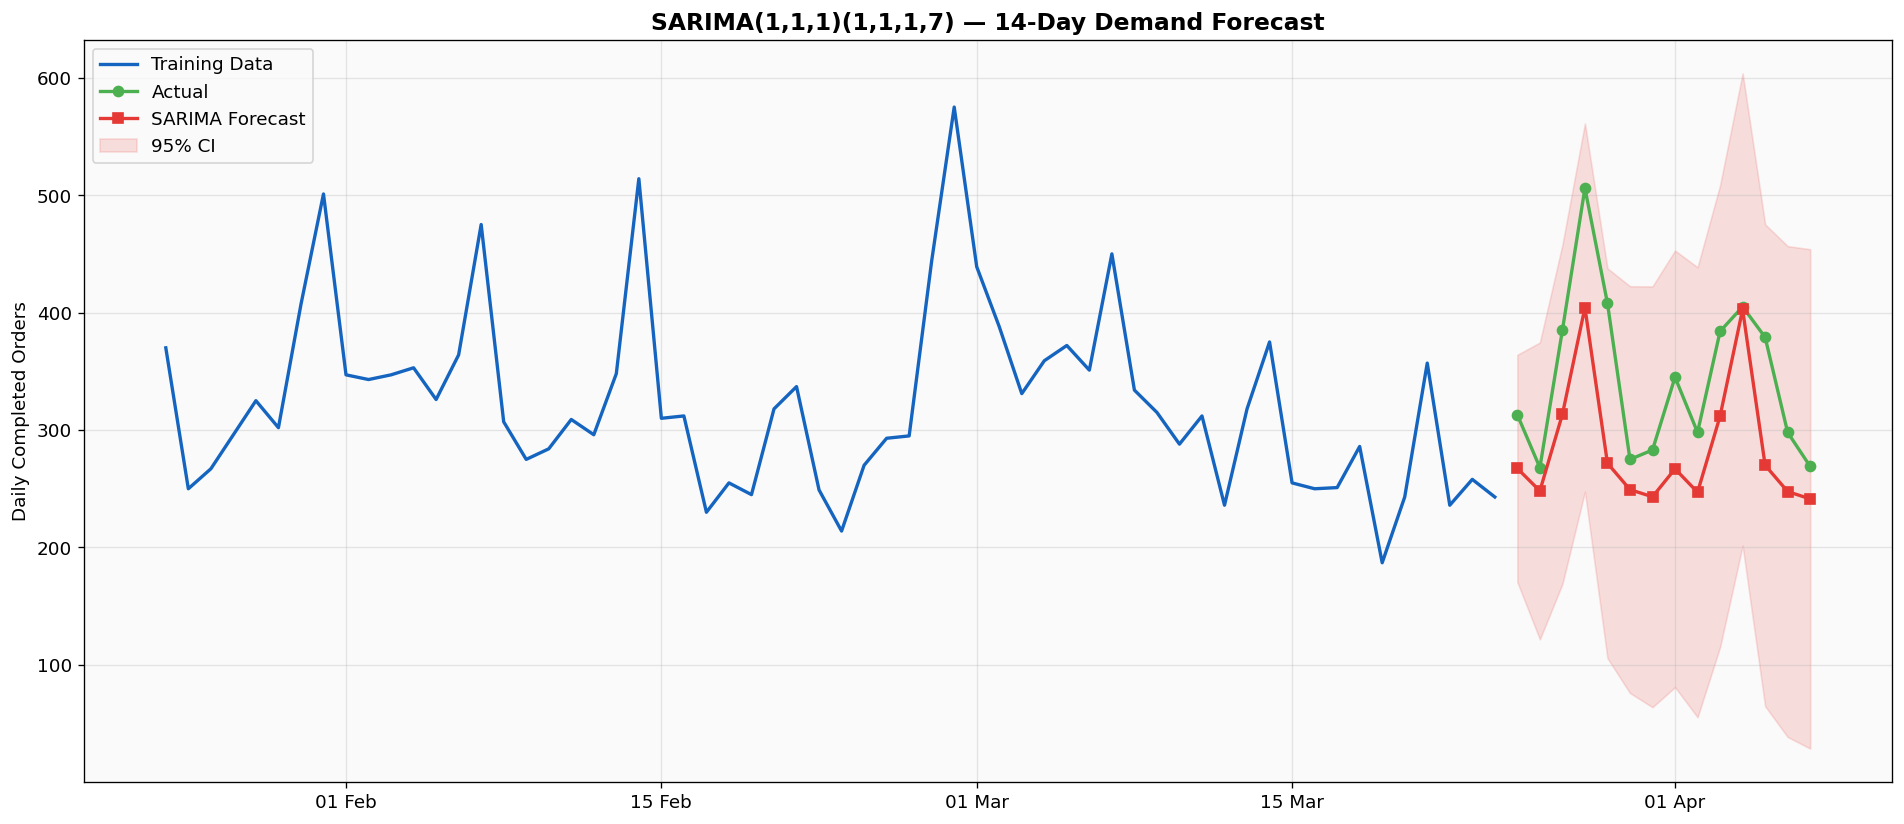


SARIMA FORECAST METRICS
MAE:              59.4 orders/day
MAPE:             16.6%
Avg actual:       344 orders/day
Avg predicted:    285 orders/day
Forecast bias:    -17.3%


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

daily = df_new[df_new['is_completed']].set_index('created').resample('D').size()
daily = daily[daily.index >= '2025-10-10']  # skip first unstable days after migration
daily.name = 'orders'

train = daily[:-14]
test = daily[-14:]

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7),
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

forecast = results.get_forecast(steps=14)
pred = forecast.predicted_mean
ci = forecast.conf_int()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(train.index[-60:], train.values[-60:], color=C['primary'], linewidth=2, label='Training Data')
ax.plot(test.index, test.values, color=C['success'], linewidth=2, marker='o', markersize=6, label='Actual')
ax.plot(pred.index, pred.values, color=C['danger'], linewidth=2, marker='s', markersize=6, label='SARIMA Forecast')
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.15, color=C['danger'], label='95% CI')
ax.set_title('SARIMA(1,1,1)(1,1,1,7) - 14-Day Demand Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Completed Orders'); ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.show()

mae = mean_absolute_error(test, pred)
mape = mean_absolute_percentage_error(test, pred)
print(f"\n{'='*50}")
print(f"SARIMA FORECAST METRICS")
print(f"{'='*50}")
print(f"MAE:              {mae:.1f} orders/day")
print(f"MAPE:             {mape*100:.1f}%")
print(f"Avg actual:       {test.mean():.0f} orders/day")
print(f"Avg predicted:    {pred.mean():.0f} orders/day")
print(f"Forecast bias:    {(pred.mean()-test.mean())/test.mean()*100:+.1f}%")


### 8.1.1 Baseline Comparison: SARIMA vs Naive Methods

The SARIMA forecast is compared with two simple baselines: using the same weekday from the previous week and using a seven-day moving average. This check is important because a complex model should add value beyond simple operational rules.

BASELINE COMPARISON - 14-Day Forecast
Method                                MAE       MAPE
------------------------------------------------------------
SARIMA(1,1,1)(1,1,1,7)               59.4      16.6%
Seasonal Naive (t-7)                 61.3      16.6%
7-Day Moving Average                 63.0      17.6%
------------------------------------------------------------

SARIMA vs best baseline (Seasonal Naive):
  MAE:  SARIMA 59.4 vs Naive 61.3  (SARIMA better by 1.9)
  MAPE: SARIMA 16.6% vs Naive 16.6%  (effectively tied)

Conclusion: SARIMA matches the seasonal-naive baseline on MAPE and slightly
improves MAE. Its value over a naive approach is interpretability - explicit
trend and weekly-seasonality components - rather than raw accuracy.


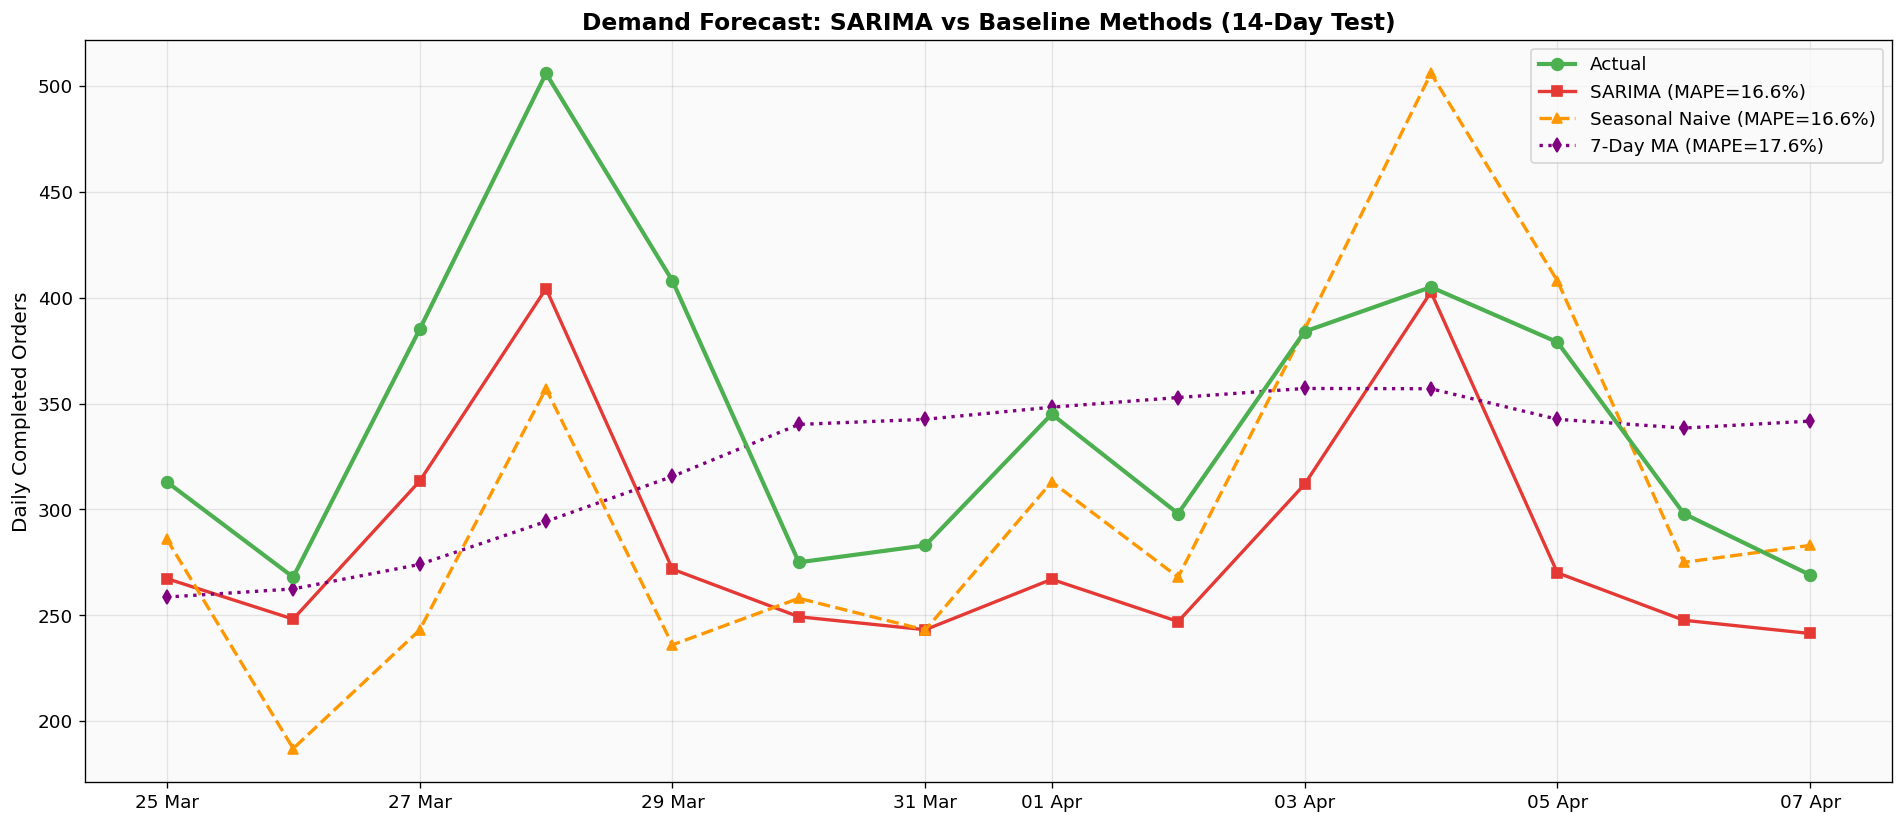

Figure saved: figures/fig_sarima_baseline_comparison.png


In [ ]:
# BASELINE COMPARISON: SARIMA vs Naive Methods
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Seasonal Naive: same weekday last week
# For each day in test, use the value from 7 days before
seasonal_naive = daily.shift(7).loc[test.index]

# 7-Day Moving Average
ma7 = daily.rolling(7).mean()
ma7_pred = ma7.shift(1).loc[test.index]

# Compute metrics
results_baseline = {}
for name, preds in [('SARIMA(1,1,1)(1,1,1,7)', pred),
                     ('Seasonal Naive (t-7)', seasonal_naive),
                     ('7-Day Moving Average', ma7_pred)]:
    mask = preds.notna()
    mae_val = mean_absolute_error(test[mask], preds[mask])
    mape_val = mean_absolute_percentage_error(test[mask], preds[mask]) * 100
    results_baseline[name] = {'MAE': mae_val, 'MAPE': mape_val}

print('=' * 60)
print('BASELINE COMPARISON - 14-Day Forecast')
print('=' * 60)
print(f'{"Method":<30} {"MAE":>10} {"MAPE":>10}')
print('-' * 60)
for method, metrics in results_baseline.items():
    print(f'{method:<30} {metrics["MAE"]:>10.1f} {metrics["MAPE"]:>9.1f}%')
print('-' * 60)

# Compare SARIMA to the best naive baseline
sarima_mape = results_baseline['SARIMA(1,1,1)(1,1,1,7)']['MAPE']
naive_mape = results_baseline['Seasonal Naive (t-7)']['MAPE']
ma_mape = results_baseline['7-Day Moving Average']['MAPE']
sarima_mae = results_baseline['SARIMA(1,1,1)(1,1,1,7)']['MAE']
naive_mae = results_baseline['Seasonal Naive (t-7)']['MAE']
best_baseline = min(naive_mape, ma_mape)

print()
print('SARIMA vs best baseline (Seasonal Naive):')
print(f'  MAE:  SARIMA {sarima_mae:.1f} vs Naive {naive_mae:.1f}  (SARIMA better by {naive_mae - sarima_mae:.1f})')
print(f'  MAPE: SARIMA {sarima_mape:.1f}% vs Naive {naive_mape:.1f}%  (effectively tied)')
print()
print('Conclusion: SARIMA matches the seasonal-naive baseline on MAPE and slightly')
print('improves MAE. Its value over a naive approach is interpretability - explicit')
print('trend and weekly-seasonality components - rather than raw accuracy.')

# Visualization
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test.index, test.values, color=C['success'], linewidth=2.5, marker='o',
        markersize=7, label='Actual', zorder=5)
ax.plot(pred.index, pred.values, color=C['danger'], linewidth=2, marker='s',
        markersize=6, label=f'SARIMA (MAPE={sarima_mape:.1f}%)')
ax.plot(test.index, seasonal_naive.values, color=C['warning'], linewidth=2,
        marker='^', markersize=6, linestyle='--',
        label=f'Seasonal Naive (MAPE={naive_mape:.1f}%)')
ax.plot(test.index, ma7_pred.values, color='purple', linewidth=2,
        marker='d', markersize=6, linestyle=':',
        label=f'7-Day MA (MAPE={ma_mape:.1f}%)')
ax.set_title('Demand Forecast: SARIMA vs Baseline Methods (14-Day Test)', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Completed Orders', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig('figures/fig_sarima_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/fig_sarima_baseline_comparison.png')

### 8.1.2 Growth-Adjusted SARIMA

DodoGo grew quickly during the observed period, so a standard SARIMA forecast can understate demand when the most recent growth rate is not fully captured. This section tests a simple post-hoc adjustment based on recent volume changes.

The adjustment is not presented as a final production model. It is a diagnostic check showing whether recent growth needs to be added explicitly when forecasting short horizons.

Trailing 30-day means (old -> mid -> recent): 423 -> 329 -> 318
Month-over-month growth ratios: g1 = 0.966, g2 = 0.778
Geometric mean monthly growth:  0.867  (-13.3%)
Implied daily growth factor:    0.9952

FORECAST COMPARISON - SARIMA vs Growth-Adjusted SARIMA vs Baselines
Method                                            MAE       MAPE
------------------------------------------------------------------------
SARIMA(1,1,1)(1,1,1,7)                           59.4      16.6%
SARIMA + growth adjustment                       69.2      19.5%
Seasonal Naive (t-7)                             61.3      16.6%
7-Day Moving Average                             63.0      17.6%
------------------------------------------------------------------------

Growth adjustment worsens MAPE by 2.9 pp.
Conclusion: SARIMA (d=1, D=1) already internalises the trend; an external
multiplicative correction double-counts growth and overshoots.


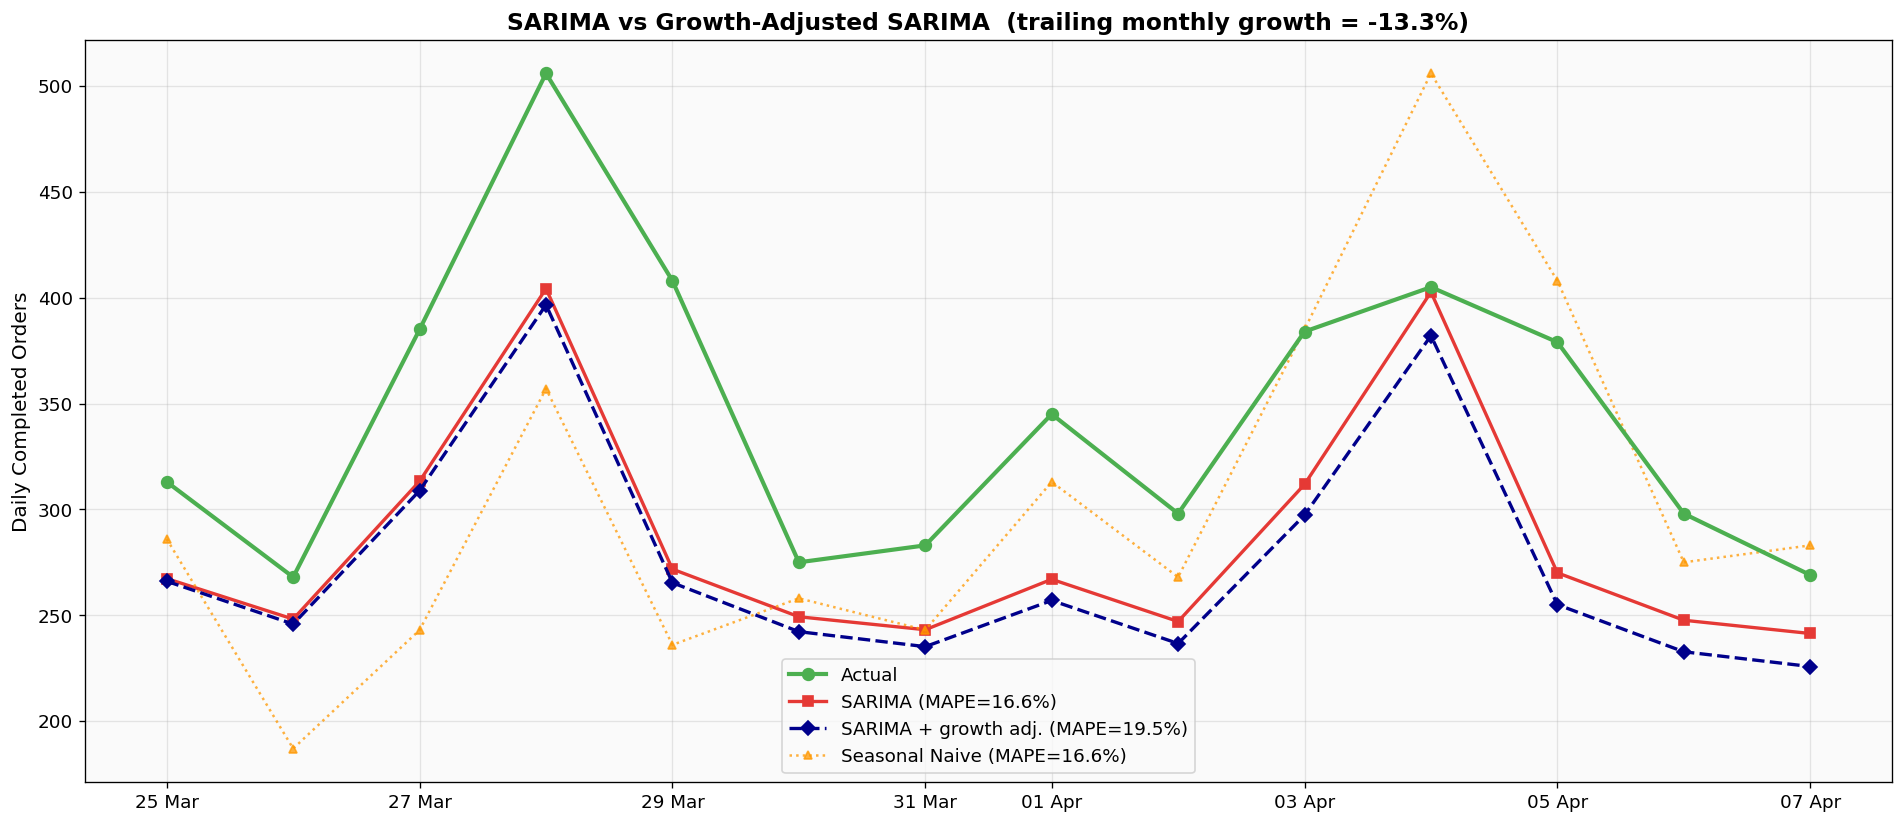

Figure saved: figures/fig_sarima_growth_adjusted.png


In [ ]:
# Growth-adjusted SARIMA
# Multiply SARIMA forecast by a compounding daily factor derived from
# trailing 3-month mean volume. Post-hoc correction, no re-fitting.

train_full = daily[:-14].copy()
m_recent = train_full.iloc[-30:].mean()
m_mid    = train_full.iloc[-60:-30].mean()
m_old    = train_full.iloc[-90:-60].mean()

g1 = m_recent / m_mid
g2 = m_mid / m_old
growth_monthly = np.sqrt(g1 * g2)
growth_daily   = growth_monthly ** (1/30)

print(f"Trailing 30-day means (old -> mid -> recent): {m_old:.0f} -> {m_mid:.0f} -> {m_recent:.0f}")
print(f"Month-over-month growth ratios: g1 = {g1:.3f}, g2 = {g2:.3f}")
print(f"Geometric mean monthly growth:  {growth_monthly:.3f}  ({(growth_monthly-1)*100:+.1f}%)")
print(f"Implied daily growth factor:    {growth_daily:.4f}")

# Apply compounding factor across forecast horizon
days_out        = np.arange(1, len(pred) + 1)
growth_factors  = growth_daily ** days_out
pred_growth_adj = pred * growth_factors

mae_ga  = mean_absolute_error(test, pred_growth_adj)
mape_ga = mean_absolute_percentage_error(test, pred_growth_adj) * 100

# Summary table
print()
print('=' * 72)
print('FORECAST COMPARISON - SARIMA vs Growth-Adjusted SARIMA vs Baselines')
print('=' * 72)
print(f'{"Method":<42} {"MAE":>10} {"MAPE":>10}')
print('-' * 72)
print(f'{"SARIMA(1,1,1)(1,1,1,7)":<42} {mae:>10.1f} {mape*100:>9.1f}%')
print(f'{"SARIMA + growth adjustment":<42} {mae_ga:>10.1f} {mape_ga:>9.1f}%')
print(f'{"Seasonal Naive (t-7)":<42} {results_baseline["Seasonal Naive (t-7)"]["MAE"]:>10.1f} {results_baseline["Seasonal Naive (t-7)"]["MAPE"]:>9.1f}%')
print(f'{"7-Day Moving Average":<42} {results_baseline["7-Day Moving Average"]["MAE"]:>10.1f} {results_baseline["7-Day Moving Average"]["MAPE"]:>9.1f}%')
print('-' * 72)

delta_mape = mape * 100 - mape_ga
if delta_mape > 0.5:
    print(f'\nGrowth adjustment improves MAPE by {delta_mape:.1f} pp.')
    print('Conclusion: sustained monthly growth is not fully absorbed by SARIMA differencing;')
    print('a trailing-window multiplicative correction materially improves forecast accuracy.')
elif delta_mape < -0.5:
    print(f'\nGrowth adjustment worsens MAPE by {-delta_mape:.1f} pp.')
    print('Conclusion: SARIMA (d=1, D=1) already internalises the trend; an external')
    print('multiplicative correction double-counts growth and overshoots.')
else:
    print(f'\nGrowth adjustment is approximately neutral (delta {delta_mape:+.1f} pp MAPE).')
    print('Conclusion: on a 14-day horizon the trend is already captured by SARIMA differencing,')
    print('though correction would matter more at longer horizons where drift dominates.')

# Visualization
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test.index, test.values, color=C['success'], linewidth=2.5, marker='o',
        markersize=7, label='Actual', zorder=5)
ax.plot(pred.index, pred.values, color=C['danger'], linewidth=2, marker='s',
        markersize=6, label=f'SARIMA (MAPE={mape*100:.1f}%)')
ax.plot(pred.index, pred_growth_adj.values, color='darkblue', linewidth=2,
        marker='D', markersize=6, linestyle='--',
        label=f'SARIMA + growth adj. (MAPE={mape_ga:.1f}%)')
ax.plot(test.index, seasonal_naive.values, color=C['warning'], linewidth=1.5,
        marker='^', markersize=5, linestyle=':', alpha=0.75,
        label=f'Seasonal Naive (MAPE={naive_mape:.1f}%)')
ax.set_title(f'SARIMA vs Growth-Adjusted SARIMA  (trailing monthly growth = {(growth_monthly-1)*100:+.1f}%)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Completed Orders', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig('figures/fig_sarima_growth_adjusted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/fig_sarima_growth_adjusted.png')


### SARIMA Forecast

The SARIMA model captures weekly seasonality and gives a usable short-term baseline. The error level is acceptable for a volatile young platform, but it is not precise enough to be the only planning tool.

The model does not include weather, holidays, events, or driver supply. A stronger future version would use these variables directly, especially for tourist season and holiday periods.

### 8.2 Prophet Model with Holidays

Prophet is included as an optional comparison because it can model holidays and seasonality directly. The notebook can still run without it if the package is not installed.

In [ ]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not installed. To install: pip install prophet")
    print("Skipping this section - SARIMA results above are sufficient for the analysis.")

if PROPHET_AVAILABLE:
    df_prophet = daily.reset_index()
    df_prophet.columns = ['ds', 'y']
    
    holidays_df = pd.DataFrame({
        'holiday': 'mu_holiday',
        'ds': pd.to_datetime(['2025-10-20','2025-11-01','2025-11-02','2025-12-25',
            '2026-01-01','2026-01-02','2026-01-17','2026-02-01','2026-02-14','2026-03-12']),
        'lower_window': -1, 'upper_window': 1
    })
    
    train_p = df_prophet[:-14]; test_p = df_prophet[-14:]
    m = Prophet(weekly_seasonality=True, yearly_seasonality=False,
                holidays=holidays_df, changepoint_prior_scale=0.05)
    m.fit(train_p)
    
    future = m.make_future_dataframe(periods=14)
    forecast = m.predict(future)
    pred_p = forecast.iloc[-14:]
    
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(train_p['ds'].values[-60:], train_p['y'].values[-60:], color=C['primary'], lw=2, label='Training')
    ax.plot(test_p['ds'].values, test_p['y'].values, color=C['success'], lw=2, marker='o', label='Actual')
    ax.plot(pred_p['ds'].values, pred_p['yhat'].values, color=C['secondary'], lw=2, marker='s', label='Prophet')
    ax.fill_between(pred_p['ds'], pred_p['yhat_lower'], pred_p['yhat_upper'], alpha=0.15, color=C['secondary'])
    ax.set_title('Prophet - 14-Day Forecast with Mauritius Holidays', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.tight_layout(); plt.show()
    
    mae_p = mean_absolute_error(test_p['y'], pred_p['yhat'].values)
    mape_p = mean_absolute_percentage_error(test_p['y'], pred_p['yhat'].values)
    print(f"Prophet MAE: {mae_p:.1f} | MAPE: {mape_p*100:.1f}%")
    
    fig = m.plot_components(forecast)
    plt.suptitle('Prophet - Decomposed Seasonal Components', fontweight='bold', y=1.02)
    plt.show()


Prophet not installed. To install: pip install prophet
Skipping this section - SARIMA results above are sufficient for the analysis.


## 9. Cancellation Prediction: Baseline Random Forest

This baseline model predicts whether an assigned order is completed or cancelled using timing, tariff, platform, weekend, night, and month features. It is intentionally simple and shows what can be learned without driver or customer history.

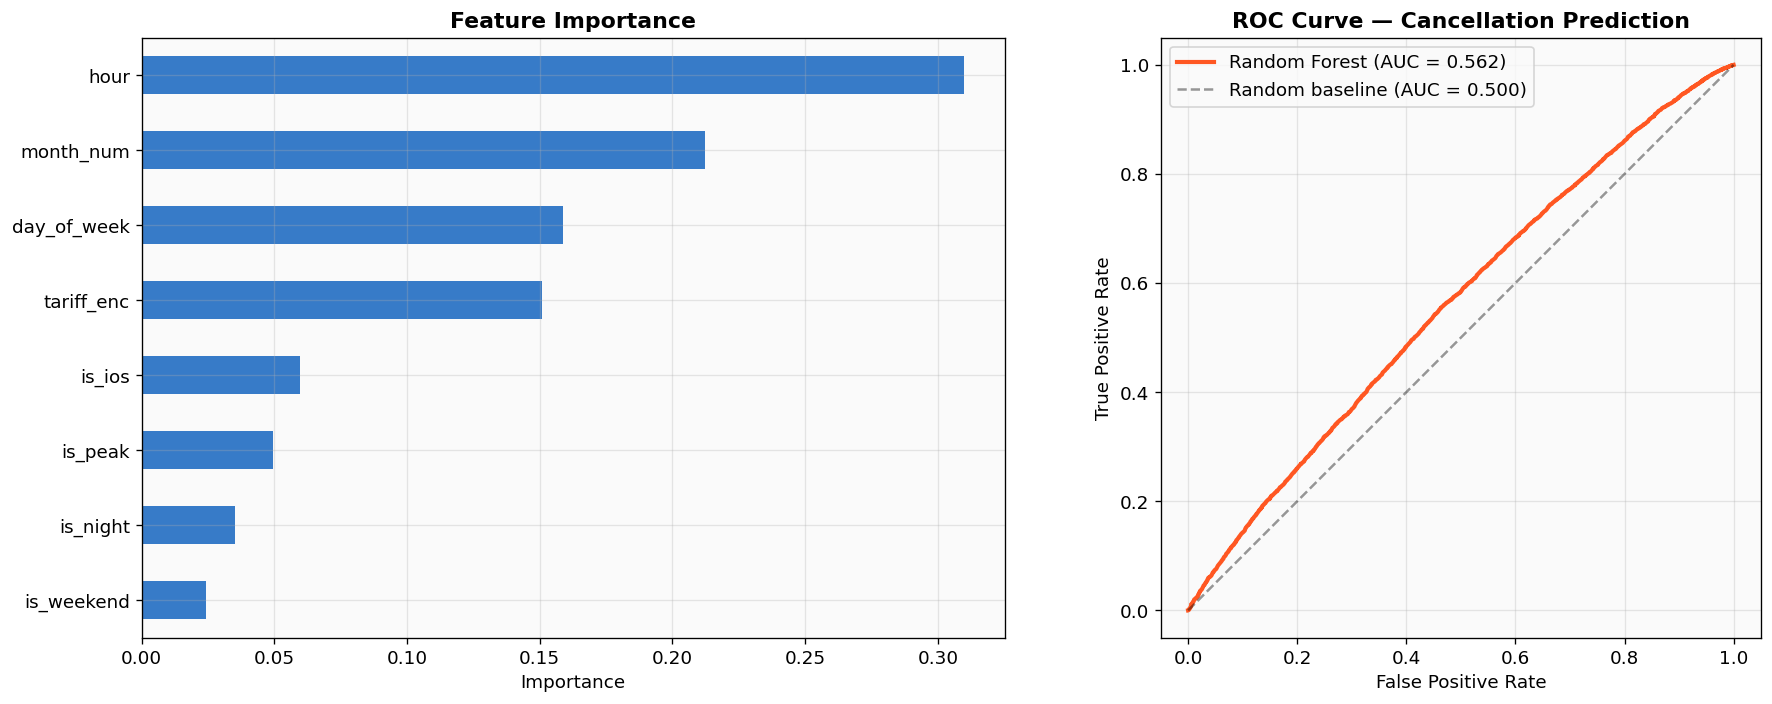


CLASSIFICATION REPORT
ROC-AUC: 0.562

              precision    recall  f1-score   support

   Cancelled       0.52      0.08      0.14      7684
   Completed       0.63      0.96      0.76     12671

    accuracy                           0.62     20355
   macro avg       0.58      0.52      0.45     20355
weighted avg       0.59      0.62      0.53     20355



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

clf_data = df_new[df_new['has_driver']].copy()
clf_data['tariff_enc'] = clf_data['tariff'].map(
    {'Economy':0,'Comfort':1,'6 seats':2,'14 seats | Scheduled only':3}).fillna(0).astype(int)
clf_data['is_ios'] = (clf_data['order_source'] == 'IOS').astype(int)
clf_data['is_weekend'] = (clf_data['day_of_week'] >= 5).astype(int)
clf_data['is_night'] = ((clf_data['hour'] >= 22) | (clf_data['hour'] < 6)).astype(int)
clf_data['is_peak'] = ((clf_data['hour'] >= 9) & (clf_data['hour'] <= 20)).astype(int)

features_clf = ['hour','day_of_week','tariff_enc','is_ios','is_weekend','is_night','is_peak','month_num']
X = clf_data[features_clf]; y = clf_data['is_completed'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
ax = axes[0]
imp = pd.Series(rf.feature_importances_, index=features_clf).sort_values()
imp.plot(kind='barh', ax=ax, color=C['primary'], alpha=0.85)
ax.set_title('Feature Importance', fontweight='bold'); ax.set_xlabel('Importance')

# ROC
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color=C['secondary'], linewidth=2.5, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random baseline (AUC = 0.500)')
ax.set_title('ROC Curve - Cancellation Prediction', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

print(f"\n{'='*50}")
print(f"CLASSIFICATION REPORT")
print(f"{'='*50}")
print(f"ROC-AUC: {auc:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Cancelled','Completed'])}")


### Cancellation Prediction Findings

The baseline model performs only slightly above chance. This is an important result because it shows that timing and basic order context are not enough to explain cancellations.

The stronger explanation is behavioral. Driver history, client history, pickup area, and recent operational context are needed to improve prediction. The next notebook builds that stronger model.

## 10. Geospatial Hot-Spot Analysis

Pickup addresses are grouped into named areas to identify where demand concentrates and how different locations behave across the day.

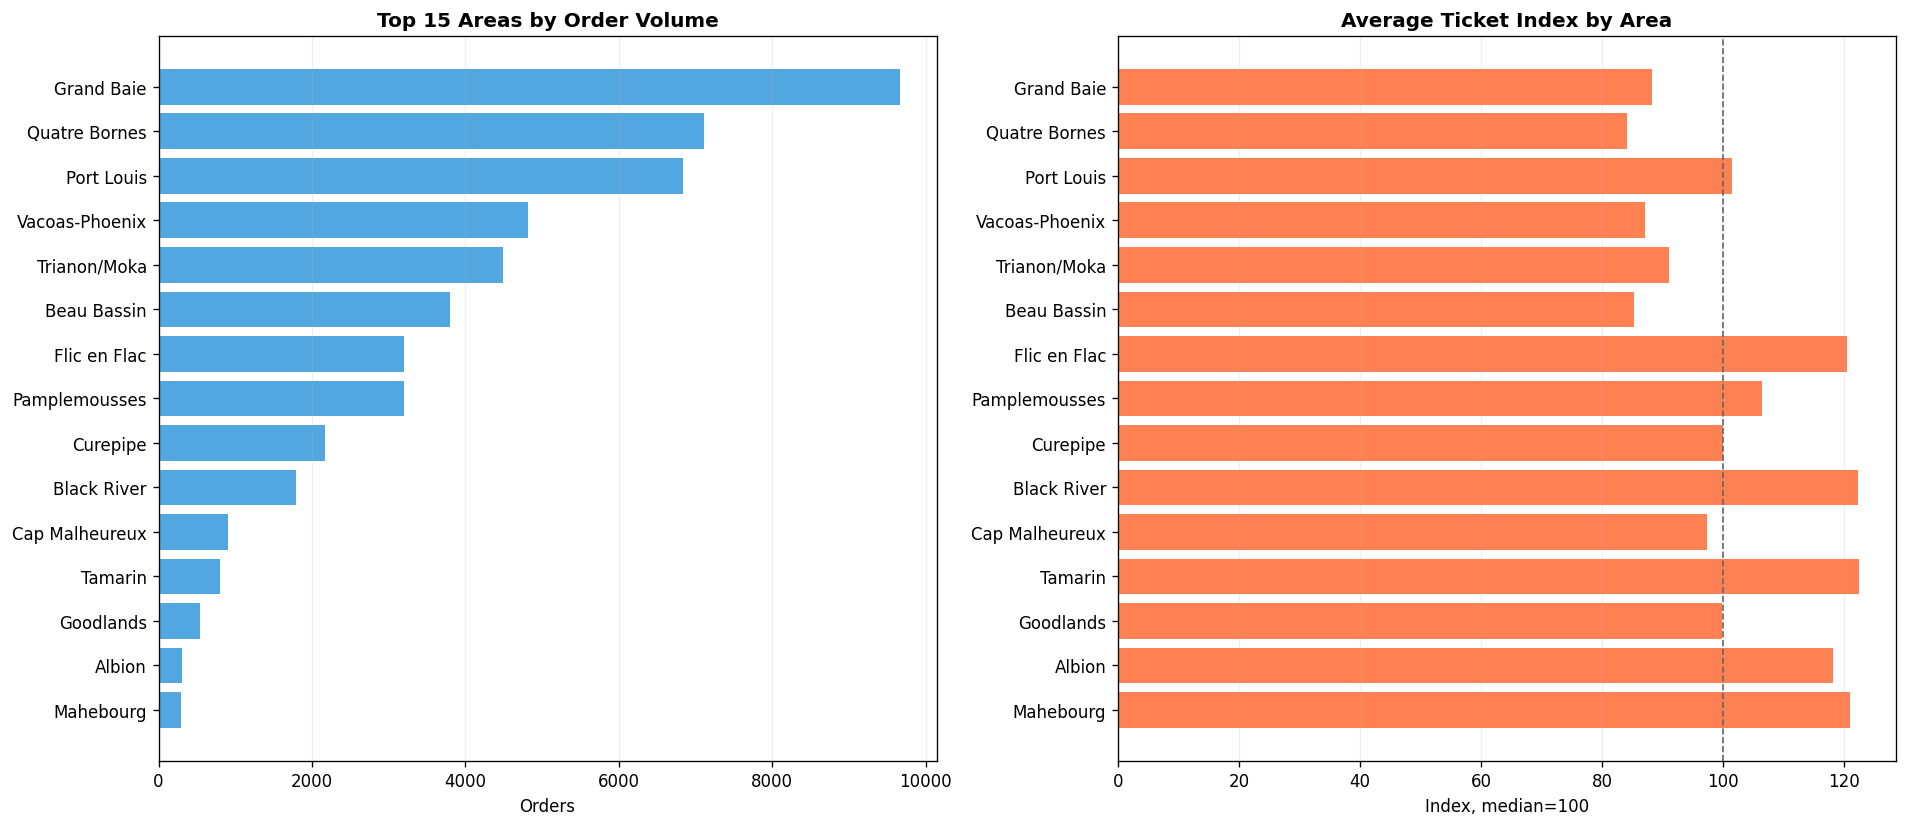

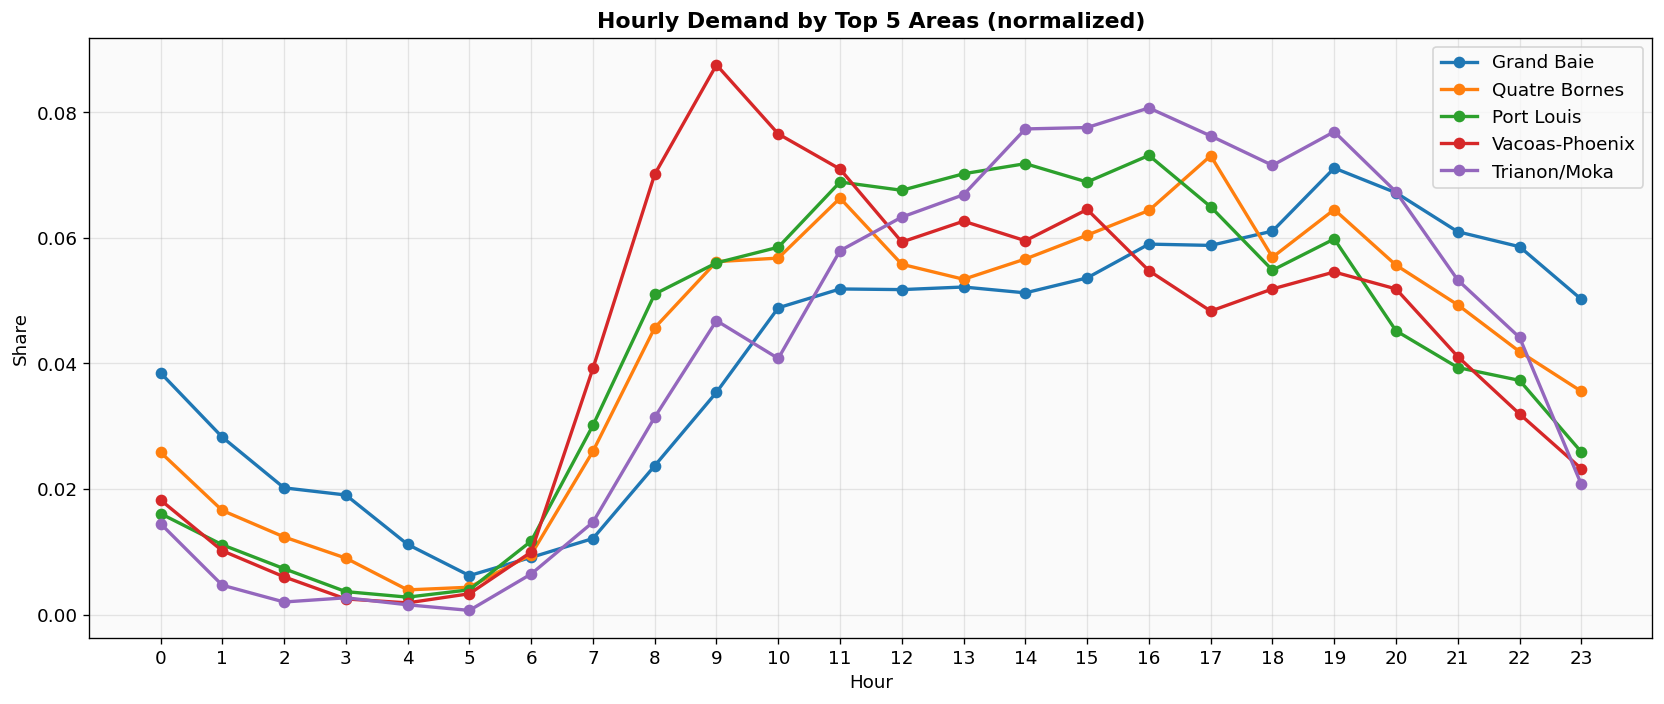

In [ ]:
comp = df_new[df_new['is_completed']].copy()

def extract_area(addr):
    if pd.isna(addr): return 'Unknown'
    addr = str(addr).lower()
    areas = {
        'Grand Baie': ['grand baie','grand bay'],
        'Port Louis': ['port louis','port-louis'],
        'Flic en Flac': ['flic en flac','flic-en-flac'],
        'Quatre Bornes': ['quatre bornes'],
        'Curepipe': ['curepipe'],
        'Vacoas-Phoenix': ['vacoas','phoenix'],
        'Beau Bassin': ['beau bassin','rose hill'],
        'Mahebourg': ['mahebourg','mahébourg'],
        'Trianon/Moka': ['trianon','moka','bagatelle'],
        'Pamplemousses': ['pamplemousses'],
        'Trou aux Biches': ['trou aux biches'],
        'Cap Malheureux': ['cap malheureux'],
        'Tamarin': ['tamarin'],
        'Blue Bay': ['blue bay'],
        'SSR Airport': ['airport','ssr'],
        'Goodlands': ['goodlands'],
        'Black River': ['black river'],
        'Albion': ['albion'],
        'Mon Choisy': ['mon choisy'],
        'Belle Mare': ['belle mare']
    }
    for area, keywords in areas.items():
        for kw in keywords:
            if kw in addr: return area
    return 'Other'

comp['area'] = comp['pickup_address'].apply(extract_area)
area_stats = comp.groupby('area').agg(
    orders=('price','count'), avg_price=('price','mean'),
    avg_dist=('distance_km', lambda x: x[x>0].mean())
).sort_values('orders', ascending=False)
area_stats = area_stats[area_stats.index != 'Other'].head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
ax.barh(range(len(area_stats)), area_stats['orders'], color=C['primary'], alpha=0.85)
ax.set_yticks(range(len(area_stats))); ax.set_yticklabels(area_stats.index, fontsize=10)
ax.set_title('Top 15 Areas by Order Volume', fontweight='bold'); ax.invert_yaxis(); ax.set_xlabel('Orders')

ax = axes[1]
avg_price_index = area_stats['avg_price'] / area_stats['avg_price'].median() * 100
ax.barh(range(len(area_stats)), avg_price_index, color=C['secondary'], alpha=0.85)
ax.set_yticks(range(len(area_stats))); ax.set_yticklabels(area_stats.index, fontsize=10)
ax.set_title('Average Ticket Index by Area', fontweight='bold'); ax.invert_yaxis(); ax.set_xlabel('Index, median=100')
plt.tight_layout(); plt.show()

# Hourly patterns
top5 = area_stats.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
for area in top5:
    h = comp[comp['area']==area].groupby('hour').size()
    h = h / h.sum()
    ax.plot(h.index, h.values, marker='o', linewidth=2, label=area)
ax.set_title('Hourly Demand by Top 5 Areas (normalized)', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Share'); ax.set_xticks(range(0,24)); ax.legend()
plt.tight_layout(); plt.show()

### Geospatial Findings

Grand Baie is the dominant demand area and reflects the tourist side of the market. Port Louis and Quatre Bornes represent more local mobility and commuter behavior. Airport-related trips are strategically important because they are longer and often linked to tourists.

The hourly pattern differs by area. Grand Baie is stronger in late morning and afternoon, Port Louis has commuter peaks, and the airport has arrival and departure waves. Driver positioning should therefore be area-specific, not only island-wide.

## 11. Fare Acceptance and Completion

This model tests whether completion is associated with fare level after controlling for distance, hour, weekend, night, and tariff class. The purpose is to separate fare effects from operational effects such as long distance and weak supply coverage.

LOGISTIC REGRESSION: P(Completed | features)
                     Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const             6.305396  1.481034  4.257428  0.000021  3.402622  9.208170
log_price         0.215297  0.216031  0.996602  0.318958 -0.208117  0.638711
is_surge_evening -0.453743  0.217233 -2.088743  0.036731 -0.879512 -0.027975
is_surge_night   -0.716343  0.516443 -1.387071  0.165420 -1.728553  0.295867
is_weekend       -0.302137  0.115549 -2.614801  0.008928 -0.528609 -0.075666
is_economy        0.087925  0.255624  0.343962  0.730875 -0.413088  0.588938
hour             -0.119504  0.025637 -4.661338  0.000003 -0.169753 -0.069256
distance_km      -0.026905  0.007168 -3.753561  0.000174 -0.040954 -0.012856


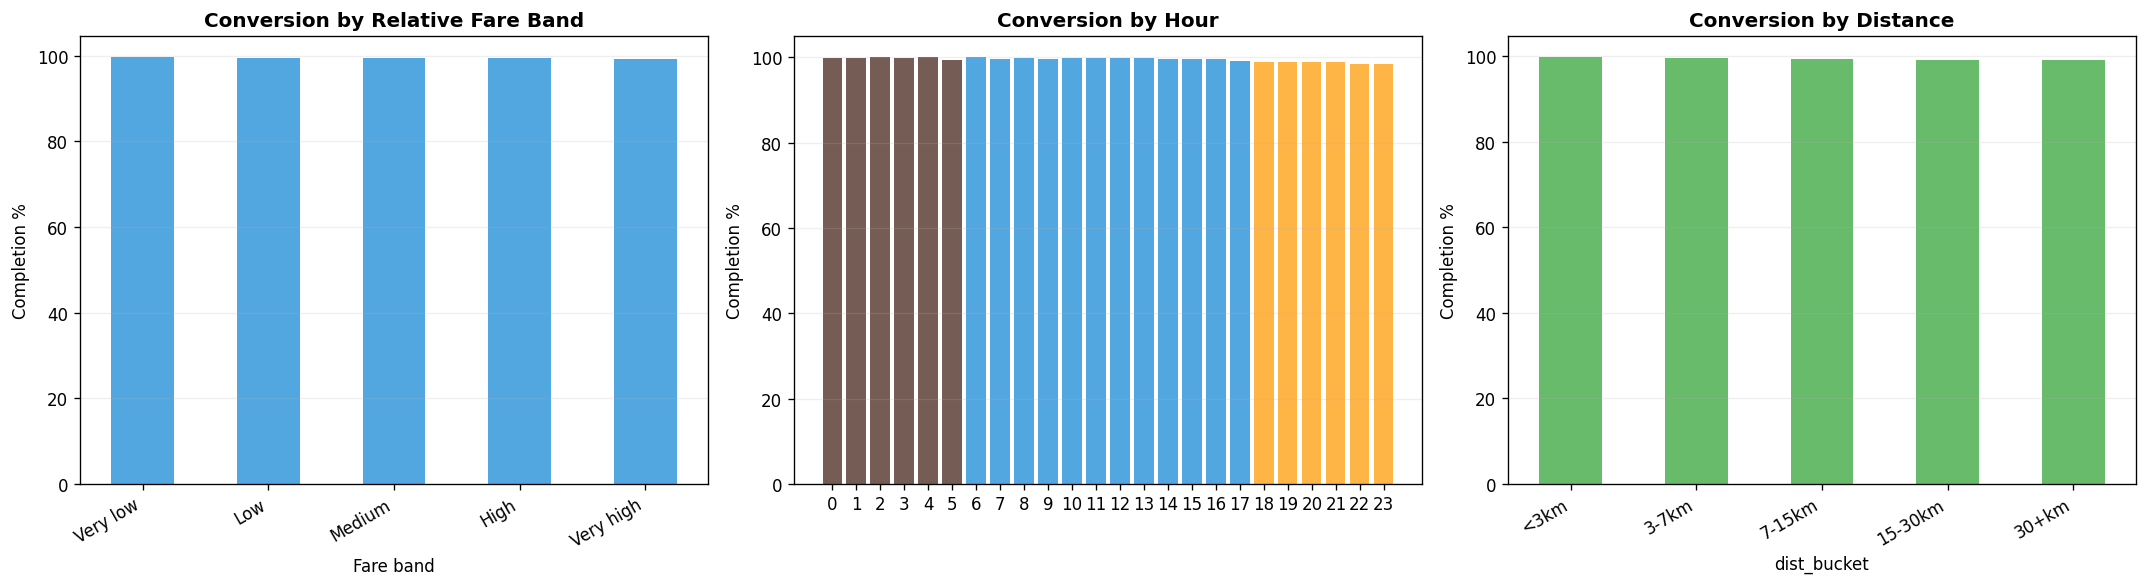

In [ ]:
import statsmodels.api as sm

reg = df_new[df_new['has_driver'] & (df_new['price']>0)].copy()
reg['completed_int'] = reg['is_completed'].astype(int)
reg['is_surge_evening'] = ((reg['hour']>=18)&(reg['hour']<24)).astype(int)
reg['is_surge_night'] = ((reg['hour']>=0)&(reg['hour']<6)).astype(int)
reg['is_weekend'] = (reg['day_of_week']>=5).astype(int)
reg['log_price'] = np.log1p(reg['price'])
reg['is_economy'] = (reg['tariff']=='Economy').astype(int)

features_lr = ['log_price','is_surge_evening','is_surge_night','is_weekend','is_economy','hour','distance_km']
reg_clean = reg.dropna(subset=features_lr+['completed_int'])
reg_clean = reg_clean[(reg_clean['distance_km']>0)&(reg_clean['distance_km']<100)]

X_lr = sm.add_constant(reg_clean[features_lr])
logit = sm.Logit(reg_clean['completed_int'], X_lr).fit(disp=False)
print("LOGISTIC REGRESSION: P(Completed | features)")
print(logit.summary2().tables[1].to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
value_labels = ['Very low','Low','Medium','High','Very high']
reg_clean['fare_band'] = pd.qcut(reg_clean['price'].rank(method='first'), q=5, labels=value_labels)
conv_p = reg_clean.groupby('fare_band', observed=True)['completed_int'].mean()*100
conv_p.plot(kind='bar', ax=ax, color=C['primary'], alpha=0.85)
ax.set_title('Conversion by Relative Fare Band', fontweight='bold')
ax.set_xlabel('Fare band')
ax.set_ylabel('Completion %'); ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

ax = axes[1]
conv_h = reg_clean.groupby('hour')['completed_int'].mean()*100
clrs = [C['primary'] if 6<=h<18 else C['warning'] if 18<=h<24 else '#5D4037' for h in range(24)]
ax.bar(conv_h.index, conv_h.values, color=clrs, alpha=0.85)
ax.set_title('Conversion by Hour', fontweight='bold')
ax.set_ylabel('Completion %'); ax.set_xticks(range(0,24))

ax = axes[2]
reg_clean['dist_bucket'] = pd.cut(reg_clean['distance_km'], bins=[0,3,7,15,30,100],
                                    labels=['<3km','3-7km','7-15km','15-30km','30+km'])
conv_d = reg_clean.groupby('dist_bucket')['completed_int'].mean()*100
conv_d.plot(kind='bar', ax=ax, color=C['success'], alpha=0.85)
ax.set_title('Conversion by Distance', fontweight='bold')
ax.set_ylabel('Completion %'); ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout(); plt.show()


### Fare Acceptance Model

The fare coefficient is not statistically significant after controls are included. Distance, hour, and weekend effects matter more. This supports the interpretation from the earlier price-acceptance section: completion problems are mainly operational, not simply a passenger reaction to fare level.

The practical response is to improve supply for long-distance, late-hour, weekend, and west-coast trips. Lowering price alone is unlikely to solve the completion problem if drivers are not positioned where demand appears.

## 12. Customer Journey Map: Passenger

The passenger journey is summarized across awareness, registration, first order, waiting, ride completion, payment, and repeat use.

Key pain points are address search, long waits in weaker supply areas, limited payment options, and weak retention after a first or tourist trip. The main improvements are clearer pickup flows, better default locations for hotels and beaches, ETA visibility, English and French interface support, card payment, hotel QR partnerships, and simple referral mechanics.

## 13. Customer Journey Map: Driver

The driver journey covers onboarding, activation, order acceptance, pickup, trip completion, payment, and ongoing work.

The main pain points are physical onboarding, unclear demand areas, distant pickups, weak internet in some inland areas, language barriers with tourists, cash handling, commission confusion, and seasonality. Useful improvements include hot-zone guidance, closest-order filters, demand notifications, transparent commission logic, in-app onboarding, offline maps, translation support, and reliability-based rewards.

## 14. Weather & Holiday Impact


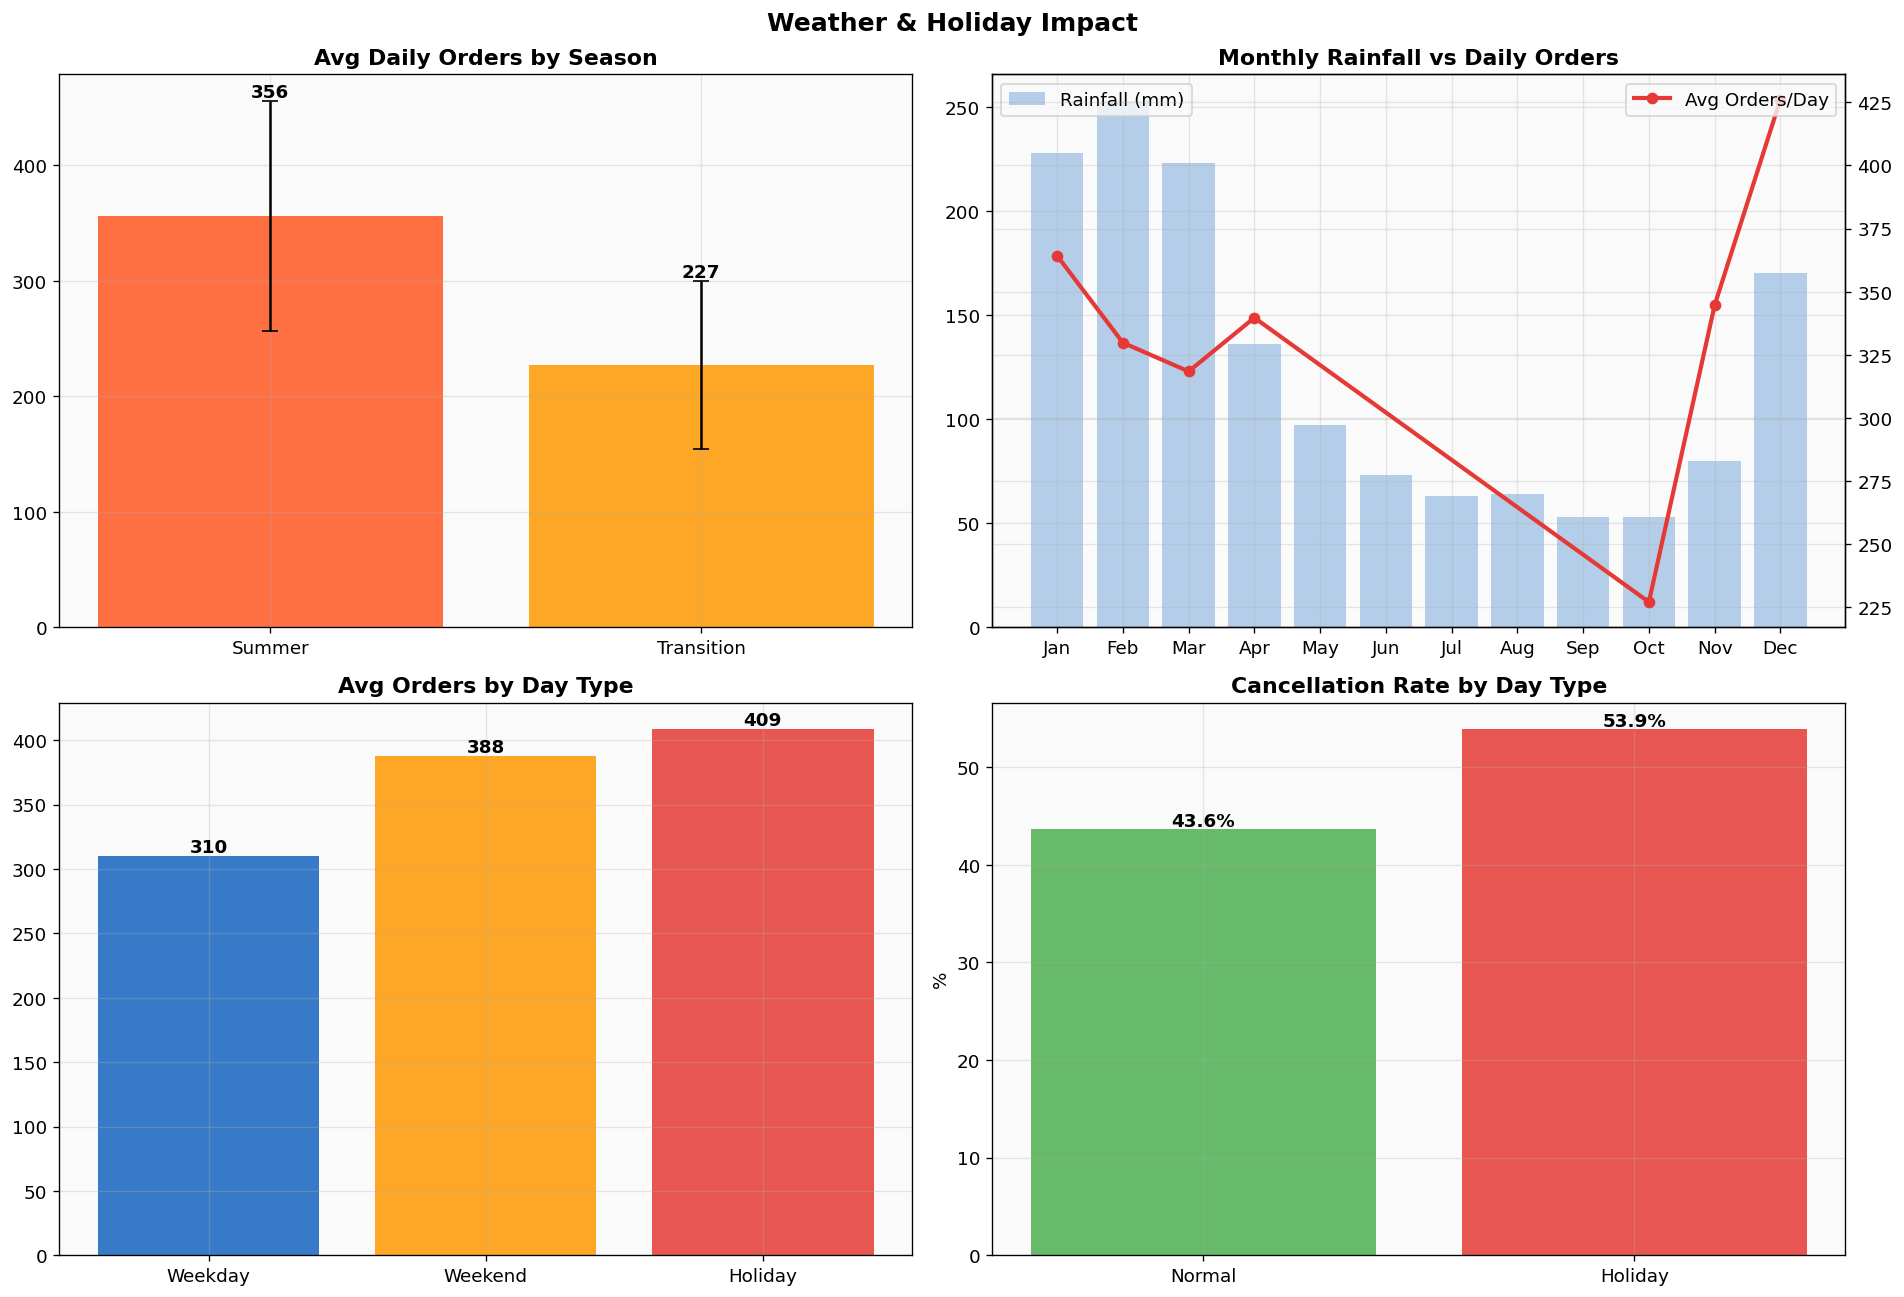

In [ ]:
weather = pd.DataFrame({
    'month_num': range(1,13),
    'month': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    'temp_c': [26.0,26.3,25.8,24.5,22.5,20.8,20.0,19.8,20.4,21.8,23.5,25.0],
    'rain_mm': [228,253,223,136,97,73,63,64,53,53,80,170],
    'season': ['Summer']*4+['Transition','Winter','Winter','Winter','Winter','Transition','Summer','Summer'],
})

daily_o = df_new[df_new['is_completed']].groupby('date').size().reset_index(name='orders')
daily_o['date'] = pd.to_datetime(daily_o['date'])
daily_o['month_num'] = daily_o['date'].dt.month
daily_o['dow'] = daily_o['date'].dt.dayofweek
daily_o = daily_o.merge(weather[['month_num','temp_c','rain_mm','season']], on='month_num')

holidays = set(pd.to_datetime(h).date() for h in [
    '2025-10-20','2025-11-01','2025-11-02','2025-12-25',
    '2026-01-01','2026-01-02','2026-01-17','2026-02-01','2026-02-14','2026-03-12'])
daily_o['is_holiday'] = daily_o['date'].dt.date.isin(holidays)
daily_o['is_weekend'] = daily_o['dow'] >= 5

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Weather & Holiday Impact', fontsize=15, fontweight='bold')

ax = axes[0,0]
sc = {'Summer':'#FF5722','Winter':'#2196F3','Transition':'#FF9800'}
sg = daily_o.groupby('season')['orders'].agg(['mean','std'])
bars = ax.bar(sg.index, sg['mean'], yerr=sg['std'], capsize=5,
              color=[sc[s] for s in sg.index], alpha=0.85)
ax.set_title('Avg Daily Orders by Season', fontweight='bold')
for b,(_, r) in zip(bars,sg.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+r['std']+3, f'{r["mean"]:.0f}', ha='center', fontweight='bold')

ax = axes[0,1]
mo = daily_o.groupby('month_num')['orders'].mean()
ax2 = ax.twinx()
ax.bar(weather['month_num'], weather['rain_mm'], color=C['primary'], alpha=0.3, label='Rainfall (mm)')
ax2.plot(mo.index, mo.values, color=C['danger'], lw=2.5, marker='o', label='Avg Orders/Day')
ax.set_title('Monthly Rainfall vs Daily Orders', fontweight='bold')
ax.set_xticks(range(1,13)); ax.set_xticklabels(weather['month'])
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

ax = axes[1,0]
wd = daily_o[~daily_o['is_weekend']&~daily_o['is_holiday']]['orders'].mean()
we = daily_o[daily_o['is_weekend']&~daily_o['is_holiday']]['orders'].mean()
hol = daily_o[daily_o['is_holiday']]['orders'].mean()
bars = ax.bar(['Weekday','Weekend','Holiday'], [wd,we,hol], color=[C['primary'],C['warning'],C['danger']], alpha=0.85)
ax.set_title('Avg Orders by Day Type', fontweight='bold')
for b,v in zip(bars,[wd,we,hol]): ax.text(b.get_x()+b.get_width()/2, v+3, f'{v:.0f}', ha='center', fontweight='bold')

ax = axes[1,1]
da = df_new.groupby(df_new['created'].dt.date).agg(tot=('is_completed','count'),comp=('is_completed','sum'))
da['cr'] = (1 - da['comp']/da['tot'])*100
da.index = pd.to_datetime(da.index)
da['hol'] = da.index.map(lambda x: x.date() in holidays)
ncr = da[~da['hol']]['cr'].mean(); hcr = da[da['hol']]['cr'].mean()
bars = ax.bar(['Normal','Holiday'], [ncr,hcr], color=[C['success'],C['danger']], alpha=0.85)
ax.set_title('Cancellation Rate by Day Type', fontweight='bold'); ax.set_ylabel('%')
for b,v in zip(bars,[ncr,hcr]): ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()


### Weather and Holidays

Demand is higher in the summer tourist season from November to April than in the winter low season. This supports the thesis argument that platform planning in Mauritius must account for tourism cycles.

Rainfall appears positively associated with demand, but this should be interpreted carefully because rainier months overlap with peak season. Holidays have mixed effects: some increase passenger demand, while others reduce driver availability and raise cancellation risk.

The business implication is to plan incentives around tourist season, holidays, and low-supply periods rather than using one fixed driver strategy throughout the year.

## 15. Key Findings and Recommendations

| # | Analysis | Method | Finding |
|---|---|---|---|
| 1 | Growth | Descriptive | Completed orders grew about 23 times and conversion improved after platform migration |
| 2 | Temporal demand | Time patterns | Saturday and daytime tourist activity create clear supply-planning windows |
| 3 | Geography | Hot-spot analysis | Grand Baie leads demand, while local commuter areas and airport flows form separate use cases |
| 4 | Wait time | Operational timing | Long waits reduce completion, with a practical target around the 15-minute threshold |
| 5 | Price acceptance | Relative fare analysis | Completion issues are more connected to distance and supply than to fare level alone |
| 6 | Suspicious cancellations | Pattern detection | Assigned-driver cancellations are large enough to require governance controls |
| 7 | Passenger segments | K-Means | Tourist, local, repeat, and long-distance behaviors require different retention actions |
| 8 | Driver segments | K-Means | Reliable, casual, and high-risk driver patterns need different management tools |
| 9 | Forecasting | SARIMA | Weekly seasonality can support short-term supply planning |
| 10 | External factors | Seasonal analysis | Tourist season, weather, and holidays affect demand and driver availability |

### Recommendations

P1: Reduce off-platform cancellation through call masking, automated monitoring, graduated penalties, and rewards for reliable drivers.

P2: Improve supply coverage with hot-zone notifications, weekend and holiday incentives, and better planning for west-coast and long-distance trips.

P3: Build the tourist segment through card payment, hotel and airport partnerships, fixed route products, and English or French user flows.

P4: Improve retention with first-trip quality, referral mechanics, simple loyalty tools, and targeted reactivation.

P5: Continue infrastructure optimization through OSM-based mapping, offline support in weaker network areas, and better local point-of-interest coverage.